<a href="https://colab.research.google.com/github/itzelts/2025-AM158-PSETS/blob/main/AM158_PSET4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PSET 4 — Model-base Control

**Due date: November 30th, 11:59 pm**

This is the last problem set and we will cover topics from LQR control to trajectory optimization and model predictive control. You will learn how to write python code to solve a trajectory when given dynamics using numerical solver.

Problem 1 - Linear system with bounded control (25pt + 10pt bonus)
- 1.1 Prove convexity (5pt)
- 1.2 Discretization of dynamics (5pt)
- 1.3 Numerical solve trajectory optimization (10pt)
- 1.4 Resolution study (5pt)
- 1.5 KKT system (Bonus) (10pt)

Problem 2 - Use linearized dynamics to design a LQR controller (25pt + 5pt bonus)
- 2.1 Lagrangian dynamics (Bonus) (5pt)
- 2.2 State space dynamics (5pt)
- 2.3 Linearize dynamics (5pt)
- 2.4 Simulate error (5pt)
- 2.5 LQR controller (10pt)

Problem 3 - Solve obstacle avoidance problem using CRISP solver (20pt)
- 3.1 Write down the problem (10pt)
- 3.2 Solve the problem using CRISP (10pt)

Problem 4 - Model predictive control on Inverted pendulum (30pt)
- 4.1 Trajectory optimization (10pt)
- 4.2 Fail of open loop control (10pt)
- 4.3 MPC control (10pt)


## Problem 1— LQR with bounded control

In class, we studied the unconstrained LQR problem solved via Bellman’s equation. In practice, inputs and states are rarely unbounded—actuators saturate and safety limits constrain the state.

For linear systems with convex constraints on inputs and states, the seminal paper [Bemporad et al., 2002](http://cse.lab.imtlucca.it/~bemporad/publications/papers/automatica-mpqp.pdf) analyzes the structure of the optimal cost-to-go (value function) and controller. We consider a finite-horizon, discrete-time linear system with fixed matrices $A, B$, deterministic dynamics, and a quadratic cost. Inputs are **bounded**.

Given $x_0$, horizon $N$, weights $Q_k \succeq 0$ for $k=0,\dots,N$ and $R_k \succ 0$ for $k=0,\dots,N-1$, and a bound $u_{\max} > 0$, consider
$$
\begin{aligned}
J(x_0) \;=\; \min_{u_0,\dots,u_{N-1}} \;&
\sum_{k=0}^{N} x_k^\top Q_k x_k \;+\; \sum_{k=0}^{N-1} u_k^\top R_k u_k \\
\text{s.t.}\;& x_{k+1} = A x_k + B u_k,\quad k=0,\dots,N-1,\\
& u_k \in [-u_{\max},\, u_{\max}] \ \text{(componentwise)},\quad k=0,\dots,N-1.
\end{aligned}
$$




### 1.1. **Convexity.**
Show the problem is a convex optimization problem when $x_0$ is fixed.

**Answer:**
We fix the initial state $x_0$ and regard the control sequence
$$
U := \begin{bmatrix} u_0 \\ u_1 \\ \vdots \\ u_{N-1} \end{bmatrix}
$$
as the decision variable. The dynamics are given by
$$
x_{k+1} = A x_k + B u_k \quad\quad \text{given }x_0
$$
and so by unrolling the recursion, we get
\begin{align*}
x_1 &= A x_0 + B u_0,\\
x_2 &= A x_1 + B u_1 = A^2 x_0 + A B u_0 + B u_1\\
&\ \,\vdots\\
x_k &= A^k x_0 + \sum_{j=0}^{k-1} A^{k-1-j} B u_j.
\end{align*}
Thus each $x_k$ is an affine function of the stacked control vector $U$.
The cost can be written as
$$
J(x_0)
= \sum_{k=0}^{N} x_k^\top Q_k x_k \;+\; \sum_{k=0}^{N-1} u_k^\top R_k u_k
$$

Now for each $k$, the term $u_k^\top R_k u_k$ is a convex quadratic in $u_k$ because $R_k \succ 0$ (positive definite). And for each $k$, the term $x_k^\top Q_k x_k$ is a convex quadratic in $x_k$ because $Q_k \succeq 0$ (positive semidefinite). Since $x_k$ is an affine function of $U$, and a convex function composed with an affine map is convex, the composition $x_k^\top Q_k x_k$ is a convex function of $U$.

A sum of convex functions is convex, so $J(x_0)$ is a convex function of $U$ (specifically a convex quadratic).

We can regard both the state sequence $X := (x_0,\dots,x_N)$ and the controls $U$ as decision variables. Then the dynamics constraints are linear equality constraints in $(x_k,u_k)$, hence convex.
And the input bounds
$$
u_k \in [-u_{\max},u_{\max}] \quad \text{(componentwise)},\quad k=0,\dots,N-1,
$$
are equivalent to linear inequalities of the form
$$
-u_{\max} \le (u_k)_i \le u_{\max} \text{ for each component } i
$$
so the feasible set for each $u_k$ is a (hyper)box, which is convex. The Cartesian product over $k$ remains convex.

Therefore, the full feasible set in $(X,U)$-space is the intersection of an affine subspace (dynamics) and a box (input bounds), and is thus convex. So with $x_0$ fixed, the problem has a convex quadratic objective in the decision variables and only linear equality and inequality constraints. Hence it is a convex quadratic program.




### 1.2. Double integrator discretization

Start from the continuous-time model $\ddot q = u,\ u \in [-1,1]$. Using $x=[q,\ \dot q]^\top$ and a fixed time step $dt$, derive the discrete system $x_{k+1} = A x_k + B u_k$.

**Answer:**  
We start from the continuous-time double integrator
$$
\ddot q(t) = u(t), \qquad u(t) \in [-1,1]
$$
and define the state
$$
x(t) =
\begin{bmatrix}
q(t) \\ \dot q(t)
\end{bmatrix}
$$
Then the continuous-time state-space model is
$$
\dot x(t)
=
\begin{bmatrix}
\dot q(t) \\ \ddot q(t)
\end{bmatrix}
=
\begin{bmatrix}
0 & 1 \\
0 & 0
\end{bmatrix}
x(t)
+
\begin{bmatrix}
0 \\ 1
\end{bmatrix}
u(t)
$$
so
$$
A_c =
\begin{bmatrix}
0 & 1 \\
0 & 0
\end{bmatrix},
\qquad
B_c =
\begin{bmatrix}
0 \\ 1
\end{bmatrix}
$$

We now discretize with sampling period $dt$ under a zero-order hold on the input, $u(t)=u_k$ for $t\in[k\,dt,(k{+}1)\,dt)$, and define
$$
x_k := x(k\,dt) \qquad u_k := u(k\,dt)
$$
Then we have
$$
\dot q_{k+1} = \dot q_k + dt\; u_k
$$
$$
q_{k+1} = q_k + dt\;\dot q_k + \tfrac{1}{2} dt^2 \; u_k
$$
This is
$$
x_{k+1}
=
\begin{bmatrix}
q_{k+1} \\ \dot q_{k+1}
\end{bmatrix}
=
\begin{bmatrix}
q_k + dt\,\dot q_k + \tfrac{1}{2} dt^2\, u_k \\
\dot q_k + dt\,u_k
\end{bmatrix}
$$

Now we can rewrite this as a linear discrete-time system
$$
x_{k+1} = A x_k + B u_k
$$
with
$$
A =
\begin{bmatrix}
1 & dt \\
0 & 1
\end{bmatrix}
\qquad
B =
\begin{bmatrix}
\tfrac{1}{2} dt^2 \\
dt
\end{bmatrix}
$$

Thus, the discrete-time double integrator is
$$
x_{k+1}
=
\begin{bmatrix}
1 & dt \\
0 & 1
\end{bmatrix}
x_k
+
\begin{bmatrix}
\tfrac{1}{2} dt^2 \\
dt
\end{bmatrix}
u_k
\qquad u_k \in [-1,1]
$$



I REALIZED I PROBABLY SHOULDVE USED FORWARD EULER METHOD BASED ON CODE COMMENT IN NEXT QUESTION

We start from the continuous-time double integrator
$$
\ddot q(t) = u(t), \qquad u(t) \in [-1,1]
$$
and define the state
$$
x(t) \;=\;
\begin{bmatrix}
q(t)\\[2pt]
\dot q(t)
\end{bmatrix}
$$
Then
$$
\dot x(t)
=
\begin{bmatrix}
\dot q(t)\\[2pt]
\ddot q(t)
\end{bmatrix}
=
\begin{bmatrix}
0 & 1\\
0 & 0
\end{bmatrix}
x(t)
+
\begin{bmatrix}
0\\[2pt]
1
\end{bmatrix}
u(t)
$$
so the continuous-time state-space matrices are
$$
A_c =
\begin{bmatrix}
0 & 1\\
0 & 0
\end{bmatrix},
\qquad
B_c =
\begin{bmatrix}
0\\[2pt]
1
\end{bmatrix}
$$

We now discretize with sampling time $dt>0$ using explicit forward Euler method. We let
$$
x_k := x(k\,dt), \qquad u_k := u(k\,dt),
$$
and approximate the time derivative as
$$
\dot x(t) \Big|_{t = k\,dt}
\;\approx\;
\frac{x_{k+1} - x_k}{dt}
$$
Substituting the continuous-time dynamics we have
$$
\frac{x_{k+1} - x_k}{dt}
\;\approx\;
A_c x_k + B_c u_k
$$
so
$$
x_{k+1}
\;\approx\;
x_k + dt\,(A_c x_k + B_c u_k)
=
\underbrace{\big(I + dt\,A_c\big)}_{A} x_k
+
\underbrace{dt\,B_c}_{B} u_k
$$

Thus the discrete-time system has the form
$$
x_{k+1} = A x_k + B u_k
$$
with
$$
A = I + dt\,A_c
=
\begin{bmatrix}
1 & dt\\
0 & 1
\end{bmatrix},
\qquad
B = dt\,B_c
=
\begin{bmatrix}
0\\[2pt]
dt
\end{bmatrix}
$$

In component form, this corresponds to the update equations
$$
\begin{aligned}
q_{k+1} &= q_k + dt\,\dot q_k,\\[2pt]
\dot q_{k+1} &= \dot q_k + dt\,u_k,
\end{aligned}
$$
which forward Euler discretization of the continuous-time double integrator $\ddot q = u$.



### 1.3 Numerical exploration

With $N=50$, $dt=0.1$, and your choice of $Q_k, R_k$, solve the problem for a grid of initial states $x_0$ (using cvxpy). Plot $J(x_0)$ and a representative control (e.g., $u_0(x_0)$).


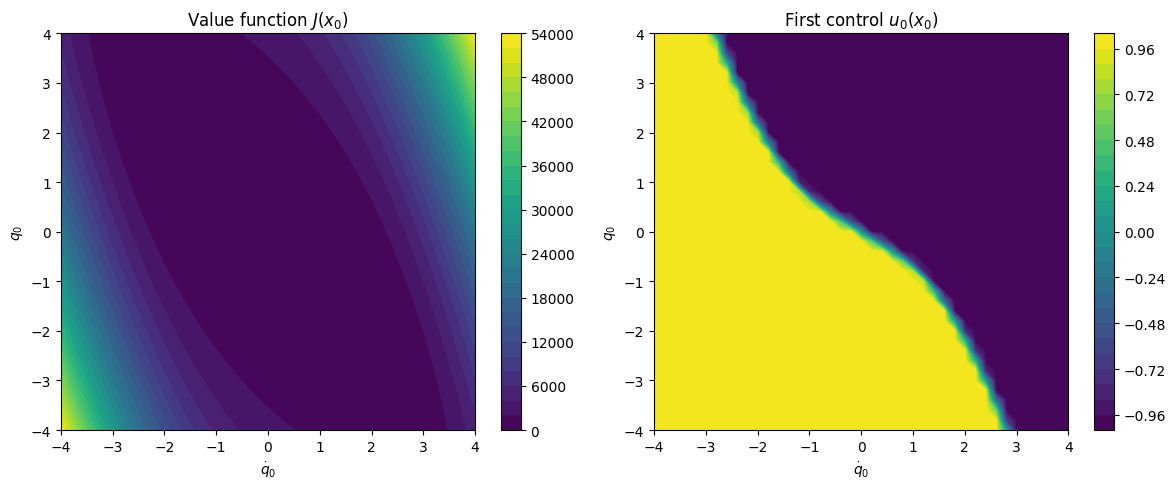

In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

# =========================
# Problem setup
# =========================

####################
# Hyperparameters
####################
N    = 50          # horizon length
dt   = 0.1         # sampling time
umax = 1.0         # input bound |u_k| <= umax

# Euler discretization for the double integrator: x = [q, qdot]
A = np.array([[1.0, dt],
              [0.0, 1.0]])
B = np.array([[0.0],
              [dt]])

# Cost weights (time-invariant)
# Penalize position more than velocity, and keep control moderate
Q = np.diag([10.0, 1.0])   # state cost
R = np.array([[0.1]])      # control cost

n, m = A.shape[0], B.shape[1]

# =========================
# Build one QP (with Parameter x0) that we can reuse for all grid points
# =========================
x = cp.Variable((n, N + 1))   # states x_0, ..., x_N
u = cp.Variable((m, N))       # controls u_0, ..., u_{N-1}
x0_param = cp.Parameter(n)      # initial condition parameter

constraints = []
# Initial condition
constraints += [x[:, 0] == x0_param]

# Dynamics and input bounds
for k in range(N):
    constraints += [x[:, k + 1] == A @ x[:, k] + B @ u[:, k]]
    constraints += [u[:, k] <=  umax]
    constraints += [u[:, k] >= -umax]

cost_terms = []
for k in range(N):
    cost_terms.append(cp.quad_form(x[:, k], Q))
    cost_terms.append(cp.quad_form(u[:, k], R))
# terminal state cost
cost_terms.append(cp.quad_form(x[:, N], Q))

objective = cp.Minimize(cp.sum(cost_terms))
prob = cp.Problem(objective, constraints)

# =========================
# Grid of initial states
# =========================

# Define a 2D grid over (q0, qdot0)
q0_vals = np.linspace(-4.0, 4.0, 41)   # position
qdot0_vals = np.linspace(-4.0, 4.0, 41)   # velocity

J_vals = np.zeros((len(q0_vals), len(qdot0_vals)))  # value function J(x0)
u0_vals = np.zeros((len(q0_vals), len(qdot0_vals)))  # first control u_0(x0)

for i, q0 in enumerate(q0_vals):
    for j, qd0 in enumerate(qdot0_vals):
        x0_param.value = np.array([q0, qd0])
        prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)
        J_vals[i, j] = prob.value
        u0_vals[i, j] = u.value[0, 0]   # first control at time k = 0

# =========================
# Plot J(x0) and u0(x0)
# =========================

Q0, QD0 = np.meshgrid(qdot0_vals, q0_vals)  # (x-axis: qdot0, y-axis: q0)

plt.figure(figsize=(12, 5))

# Plot value function J(x0)
plt.subplot(1, 2, 1)
cont1 = plt.contourf(Q0, QD0, J_vals, levels=30)
plt.colorbar(cont1)
plt.xlabel(r'$\dot q_0$')
plt.ylabel(r'$q_0$')
plt.title(r'Value function $J(x_0)$')

# Plot first control u_0(x0)
plt.subplot(1, 2, 2)
cont2 = plt.contourf(Q0, QD0, u0_vals, levels=30)
plt.colorbar(cont2)
plt.xlabel(r'$\dot q_0$')
plt.ylabel(r'$q_0$')
plt.title(r'First control $u_0(x_0)$')

plt.tight_layout()
plt.show()


### 1.4 Resolution study

Increase $N$, decrease $dt$, and plot $J,u$ on a denser grid of initial states. What can you observe from the plots? Comment on solver runtime.

**Answer:**


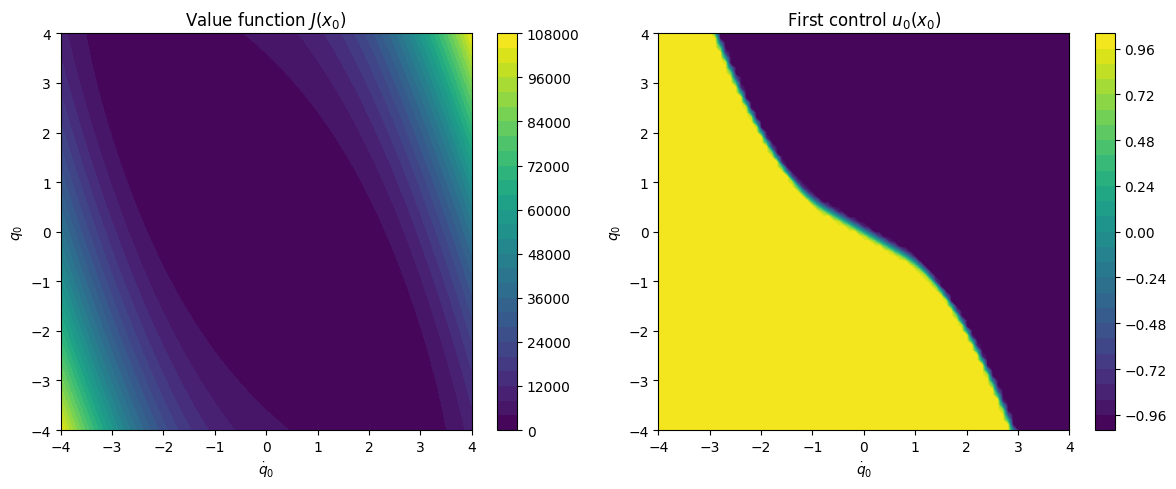

In [3]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

# =========================
# Problem setup
# =========================

####################
# Hyperparameters
####################
N    = 100          # horizon length
dt   = 0.05         # sampling time
umax = 1.0         # input bound |u_k| <= umax

# Euler discretization for the double integrator: x = [q, qdot]
A = np.array([[1.0, dt],
              [0.0, 1.0]])
B = np.array([[0.0],
              [dt]])

# Cost weights (time-invariant)
# Penalize position more than velocity, and keep control moderate
Q = np.diag([10.0, 1.0])   # state cost
R = np.array([[0.1]])      # control cost

n, m = A.shape[0], B.shape[1]

# =========================
# Build one QP (with Parameter x0) that we can reuse for all grid points
# =========================

x = cp.Variable((n, N + 1))   # states x_0, ..., x_N
u = cp.Variable((m, N))       # controls u_0, ..., u_{N-1}
x0_param = cp.Parameter(n)      # initial condition parameter

constraints = []
# Initial condition
constraints += [x[:, 0] == x0_param]

# Dynamics and input bounds
for k in range(N):
    constraints += [x[:, k + 1] == A @ x[:, k] + B @ u[:, k]]
    constraints += [u[:, k] <=  umax]
    constraints += [u[:, k] >= -umax]

cost_terms = []
for k in range(N):
    cost_terms.append(cp.quad_form(x[:, k], Q))
    cost_terms.append(cp.quad_form(u[:, k], R))
# terminal state cost
cost_terms.append(cp.quad_form(x[:, N], Q))

objective = cp.Minimize(cp.sum(cost_terms))
prob = cp.Problem(objective, constraints)

# =========================
# Grid of initial states
# =========================

# Define a 2D grid over (q0, qdot0)
q0_vals = np.linspace(-4.0, 4.0, 81)   # position
qdot0_vals = np.linspace(-4.0, 4.0, 81)   # velocity

J_vals = np.zeros((len(q0_vals), len(qdot0_vals)))  # value function J(x0)
u0_vals = np.zeros((len(q0_vals), len(qdot0_vals)))  # first control u_0(x0)

for i, q0 in enumerate(q0_vals):
    for j, qd0 in enumerate(qdot0_vals):
        x0_param.value = np.array([q0, qd0])
        prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)
        J_vals[i, j] = prob.value
        u0_vals[i, j] = u.value[0, 0]   # first control at time k = 0

# =========================
# Plot J(x0) and u0(x0)
# =========================

Q0, QD0 = np.meshgrid(qdot0_vals, q0_vals)  # (x-axis: qdot0, y-axis: q0)

plt.figure(figsize=(12, 5))

# Plot value function J(x0)
plt.subplot(1, 2, 1)
cont1 = plt.contourf(Q0, QD0, J_vals, levels=30)
plt.colorbar(cont1)
plt.xlabel(r'$\dot q_0$')
plt.ylabel(r'$q_0$')
plt.title(r'Value function $J(x_0)$')

# Plot first control u_0(x0)
plt.subplot(1, 2, 2)
cont2 = plt.contourf(Q0, QD0, u0_vals, levels=30)
plt.colorbar(cont2)
plt.xlabel(r'$\dot q_0$')
plt.ylabel(r'$q_0$')
plt.title(r'First control $u_0(x_0)$')

plt.tight_layout()
plt.show()


N=50, dt=0.1, grid=41x41, elapsed=23.68s


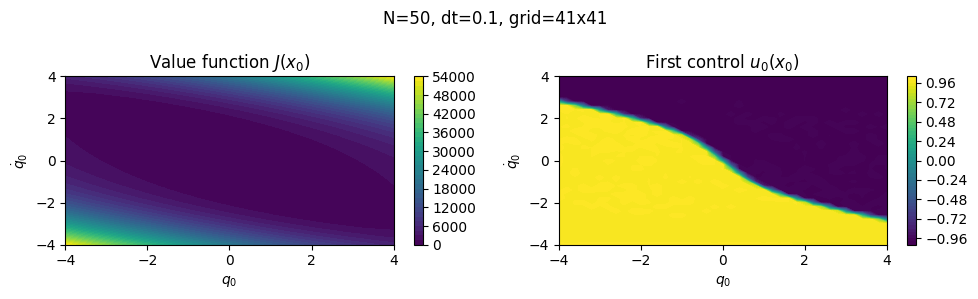

In [4]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import time

def run_config(N, dt, grid_n, umax=1.0):
    # -------------------------
    # Discretization (Euler) for double integrator: x = [q, qdot]
    # -------------------------
    A = np.array([[1.0, dt],
                  [0.0, 1.0]])
    B = np.array([[0.0],
                  [dt]])
    n, m = A.shape[0], B.shape[1]

    # -------------------------
    # Cost weights
    # -------------------------
    Q  = np.diag([10.0, 1.0])
    R  = np.array([[0.1]])

    # -------------------------
    # Build one QP with x0 as Parameter
    # -------------------------
    x = cp.Variable((n, N+1))
    u = cp.Variable((m, N))
    x0_param = cp.Parameter(n)

    constraints = [x[:, 0] == x0_param]
    for k in range(N):
        constraints += [
            x[:, k+1] == A @ x[:, k] + B @ u[:, k],
            cp.abs(u[:, k]) <= umax
        ]

    cost = 0
    for k in range(N):
        cost += cp.quad_form(x[:, k], Q) + cp.quad_form(u[:, k], R)
    cost += cp.quad_form(x[:, N], Q)

    prob = cp.Problem(cp.Minimize(cost), constraints)

    # -------------------------
    # Grid of initial states
    # -------------------------
    q_vals  = np.linspace(-4, 4, grid_n)
    qd_vals = np.linspace(-4, 4, grid_n)
    J_grid  = np.zeros((grid_n, grid_n))
    U0_grid = np.zeros((grid_n, grid_n))

    t0 = time.perf_counter()
    for i, q0 in enumerate(q_vals):
        for j, qd0 in enumerate(qd_vals):
            x0_param.value = np.array([q0, qd0])
            prob.solve(solver=cp.OSQP, warm_start=True, verbose=False)
            J_grid[j, i]  = prob.value
            U0_grid[j, i] = u.value[0, 0]
    elapsed = time.perf_counter() - t0
    print(f"N={N}, dt={dt}, grid={grid_n}x{grid_n}, elapsed={elapsed:.2f}s")

    # -------------------------
    # Plots
    # -------------------------
    Q0, QD0 = np.meshgrid(q_vals, qd_vals)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))

    im0 = axes[0].contourf(Q0, QD0, J_grid, levels=50)
    axes[0].set_title(r"Value function $J(x_0)$")
    axes[0].set_xlabel(r"$q_0$")
    axes[0].set_ylabel(r"$\dot q_0$")
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].contourf(Q0, QD0, U0_grid, levels=50,
                           vmin=-umax, vmax=umax)
    axes[1].set_title(r"First control $u_0(x_0)$")
    axes[1].set_xlabel(r"$q_0$")
    axes[1].set_ylabel(r"$\dot q_0$")
    fig.colorbar(im1, ax=axes[1])

    fig.suptitle(f"N={N}, dt={dt}, grid={grid_n}x{grid_n}")
    plt.tight_layout()
    plt.show()

run_config(N=50, dt=0.1, grid_n=41)




N=100, dt=0.05, grid=81x81, elapsed=196.21s


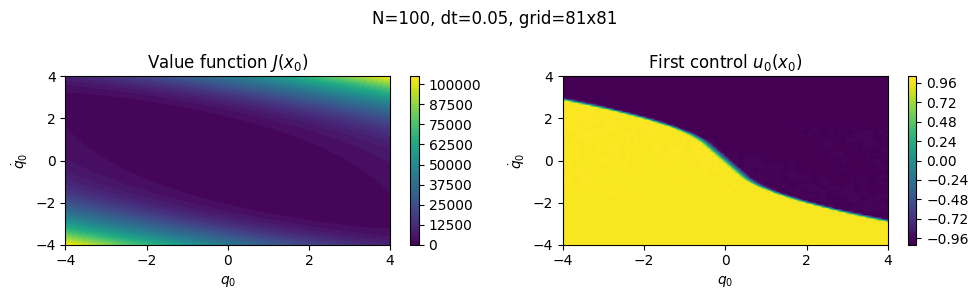

In [5]:
run_config(N=100, dt=0.05, grid_n=81)


I repeated the computation of $J(x_0)$ and $u_0(x_0)$ with a longer,
finer horizon and a denser grid of initial conditions.  In the first
setting we used
$$
N = 50,\quad dt = 0.1,\quad \text{grid } 41\times 41
$$
while in the second setting I used
$$
N = 100,\quad dt = 0.05,\quad \text{grid } 81\times 81
$$
Note that in both cases the total prediction horizon in continuous
time is the same, $T = N\,dt = 5$s, but the second setting has twice
as many time steps and roughly four times as many grid points.

From the plots of $J(x_0)$ we observe that the qualitative shape of
the value function does not change: it is small near the origin and
grows as $|q_0|$ and $|\dot q_0|$ increase, with strong penalties when
the initial position is far from the origin.  With the finer
discretization $(N=100,dt=0.05)$ and denser grid, the level sets of
$J(x_0)$ look smoother and less “blocky,” reflecting a better
approximation of the underlying continuous–time optimal control
problem.

For the first control $u_0(x_0)$, both parameter settings show the same
basic structure: a central region around the origin where the optimal
input is unsaturated and varies approximately linearly with
$(q_0,\dot q_0)$, and outer regions where $u_0$ saturates at
$\pm u_{\max}$.  As we increase $N$ and decrease
$dt$, the switching boundary between the saturated and unsaturated
regions becomes smoother and better resolved on the grid.  The overall
geometry of the switching surface, however, is consistent across both
experiments, which suggests that the coarse setting already captures
the main qualitative behavior of the constrained LQR controller.

The main downside of refining $N$, $dt$, and the grid is solver
runtime.  In our runs, the coarse case $(N=50,dt=0.1,$ $41\times 41)$
took about $24$ seconds, while the refined case
$(N=100,dt=0.05,$ $81\times 81)$ took about $196$ seconds.  This
roughly $8\times$ slowdown is consistent with the fact that we doubled
the horizon length in discrete time and increased the number of grid
points by about a factor of four, so the total number of QP solves and
decision variables scales approximately like $N \times
(\text{# grid points})$.




### 1.5 KKT conditions (Bonus)
Write the KKT optimality conditions for the problem.

**Answer:**  
We treat the decision variables as
$$
\{x_k\}_{k=1}^{N},\quad \{u_k\}_{k=0}^{N-1}
$$
with $x_0$ fixed. The constraints are
$$
x_{k+1} - A x_k - B u_k = 0,\quad k=0,\dots,N-1
$$
and the box constraints on each component of $u_k$
$$
-u_{\max} \le u_k \le u_{\max},\quad k=0,\dots,N-1
$$
Now we introduce Lagrange multipliers
$$
\lambda_k \in \mathbb{R}^n \quad\text{for } x_{k+1}-Ax_k-Bu_k=0,\ k=0,\dots,N-1
$$
and, for each $k$ and each input component, nonnegative multipliers
$$
\mu_k \in \mathbb{R}^m_{\ge 0} \quad\text{for } u_k - u_{\max} \le 0
$$
$$
\nu_k \in \mathbb{R}^m_{\ge 0} \quad\text{for } -u_k - u_{\max} \le 0
$$
The Lagrangian is
$$
\begin{aligned}
L &=
\sum_{k=0}^{N} x_k^\top Q_k x_k
+ \sum_{k=0}^{N-1} u_k^\top R_k u_k \\
&\quad
+ \sum_{k=0}^{N-1} \lambda_k^\top (A x_k + B u_k - x_{k+1})
+ \sum_{k=0}^{N-1} \mu_k^\top (u_k - u_{\max})
+ \sum_{k=0}^{N-1} \nu_k^\top (-u_k - u_{\max})
\end{aligned}
$$
The KKT conditions are
1. Feasibility:
$$
\begin{aligned}
&x_{k+1} = A x_k + B u_k,\quad k=0,\dots,N-1, \\
&-u_{\max} \le u_k \le u_{\max},\quad k=0,\dots,N-1, \\
&x_0 \text{ is fixed}
\end{aligned}
$$
2. Statinarity: For states $x_k$,
$$
\begin{aligned}
&\frac{\partial L}{\partial x_k} = 2 Q_k x_k + A^\top \lambda_{k-1} - \lambda_k = 0,
\quad k=1,\dots,N-1, \\
&\frac{\partial L}{\partial x_N} = 2 Q_N x_N - \lambda_{N-1} = 0.
\end{aligned}
$$
(There is no stationarity condition for $x_0$ since it is not a decision variable)
For inputs $u_k$,
$$
\frac{\partial L}{\partial u_k}
= 2 R_k u_k + B^\top \lambda_k + \mu_k - \nu_k = 0,
\quad k=0,\dots,N-1
$$

3. Dual Feasibility:
$$
\mu_k \ge 0,\quad \nu_k \ge 0,\quad k=0,\dots,N-1
$$

4. Slackness: $$
\mu_{k,i}\,\big(u_{k,i} - (u_{\max})_i\big) = 0,
\qquad
\nu_{k,i}\,\big(-u_{k,i} - (u_{\max})_i\big) = 0
\quad k=0,\dots,N-1
$$
Because the problem is convex (quadratic objective, affine constraints) and the box constraints admit interior points, these KKT conditions are necessary and sufficient for optimality.


## Problem 2 — Cart–Pole system (linearization + LQR)

We consider a cart of mass $m_c$ moving on a horizontal track with a pendulum (mass $m_p$, length $l$) hinged to the cart. The input $f$ is a horizontal force applied to the cart. We assume no friction and model the pendulum as a point mass at its tip. See the [Video](https://www.youtube.com/watch?v=Bzq96V1yN5k).

<figure style="text-align:center;">
  <img src="https://raw.githubusercontent.com/ComputationalRobotics/2025-ES-AM-158-PSET/main/PSET4/cartpole.png" width="360" alt="Inscribed polygon">
  <figcaption style="color:#6a737d; font-style:italic;">
    Figure 1. Cartpole.
  </figcaption>
</figure>

With this setup, we parameterize the system by two scalars: $x$ denotes the cart position, and $\theta$ is the angle between the pole and the stable equilibrium. Our goal is to study the cart–pole dynamics under the horizontal control force $f$.




### 2.1 Lagrangian derivation (Bonus)
For those of you who have background in rigid-body dynamics, this is an opportunity for you to apply your knowledge. However, feel free to skip this subproblem and it won’t affect the rest of the exercise. Derive the equations of motion:

$$
\begin{aligned}
(m_c + m_p)\,\ddot{x} + m_p\,l\,\ddot{\theta}\cos\theta - m_p\,l\,\dot{\theta}^2\sin\theta &= f, \\
m_p\,l\,\ddot{x}\cos\theta + m_p\,l^2\,\ddot{\theta} + m_p\,g\,l\,\sin\theta &= 0.
\end{aligned}
$$
(Hints: compute the Lagrangian of the system and the corresponding Lagrangian equations. Analyzing the two objects separately also works.)

**Answer:**
We choose generalized coordinates
$$
q_1 = x,\qquad q_2 = \theta,
$$
with velocities $\dot q_1 = \dot x$, $\dot q_2 = \dot\theta$ The cart (mass $m_c$) is at $(x,0)$.  
The pendulum mass $m_p$ (length l, angle theta from the upright) has position
$$
x_p = x + l\sin\theta,\qquad
y_p = l\cos\theta
$$
Then
$$
\dot x_p = \dot x + l\dot\theta\cos\theta,\qquad
\dot y_p = -\,l\dot\theta\sin\theta
$$
so its speed satisfies
$$
v_p^2
= \dot x_p^2 + \dot y_p^2
= \dot x^2 + 2l\dot x\dot\theta\cos\theta + l^2\dot\theta^2
$$
The cart and pendulum kinetic energy is
$$
T_c = \frac{1}{2}m_c \dot x^2,\qquad
T_p = \frac{1}{2}m_p v_p^2
= \frac{1}{2}m_p\big(\dot x^2 + 2l\dot x\dot\theta\cos\theta + l^2\dot\theta^2\big)
$$
hence the total kinetic energy is
$$
T
= T_c + T_p
= \frac{1}{2}(m_c+m_p)\dot x^2
 + m_p l\dot x\dot\theta\cos\theta
 + \frac{1}{2}m_p l^2\dot\theta^2
$$
Taking the pivot as zero potential and \(y\) upward,
$$
V = -\,m_p g y_p = -\,m_p g l\cos\theta
$$
The Lagrangian is
$$
L = T - V
= \frac{1}{2}(m_c+m_p)\dot x^2
 + m_p l\dot x\dot\theta\cos\theta
 + \frac{1}{2}m_p l^2\dot\theta^2
 + m_p g l\cos\theta
$$
The generalized forces are
$$
Q_x = f, \qquad Q_\theta = 0
$$
The Euler-Lagrange equations
$$
\frac{d}{dt}\Big(\frac{\partial L}{\partial \dot q_i}\Big)
- \frac{\partial L}{\partial q_i}
= Q_i
$$
yield the dynamics.
First,
$$
\frac{\partial L}{\partial \dot x}
= (m_c+m_p)\dot x + m_p l\dot\theta\cos\theta,
$$
$$
\frac{d}{dt}\Big(\frac{\partial L}{\partial \dot x}\Big)
= (m_c+m_p)\ddot x
 + m_p l\ddot\theta\cos\theta
 - m_p l\dot\theta^2\sin\theta
$$
Since $\partial L/\partial x = 0$, we obtain
$$
(m_c+m_p)\ddot x
 + m_p l\ddot\theta\cos\theta
 - m_p l\dot\theta^2\sin\theta
= f
$$
Second,
$$
\frac{\partial L}{\partial \dot\theta}
= m_p l\dot x\cos\theta + m_p l^2\dot\theta,
$$
$$
\frac{d}{dt}\Big(\frac{\partial L}{\partial \dot\theta}\Big)
= m_p l\ddot x\cos\theta
 - m_p l\dot x\dot\theta\sin\theta
 + m_p l^2\ddot\theta
$$
Only the cross term and potential depend on $\theta$ so
$$
\frac{\partial L}{\partial \theta}
= -m_p l\dot x\dot\theta\sin\theta - m_p g l\sin\theta
$$
Euler--Lagrange for $\theta$ with $Q_\theta=0$ gives
\begin{align*}
&m_p l\ddot x\cos\theta
 - m_p l\dot x\dot\theta\sin\theta
 + m_p l^2\ddot\theta
 -\big(-m_p l\dot x\dot\theta\sin\theta - m_p g l\sin\theta\big) = 0\\
\Longrightarrow\;&
m_p l\ddot x\cos\theta + m_p l^2\ddot\theta + m_p g l\sin\theta = 0
\end{align*}

Thus the equations of motion are
$$
\boxed{
\begin{aligned}
(m_c + m_p)\,\ddot{x} + m_p\,l\,\ddot{\theta}\cos\theta - m_p\,l\,\dot{\theta}^2\sin\theta &= f \\
m_p\,l\,\ddot{x}\cos\theta + m_p\,l^2\,\ddot{\theta} + m_p\,g\,l\,\sin\theta &= 0
\end{aligned}}
$$


### 2.2 State–space form.
Let $x_1=x$, $x_2=\theta$, $x_3=\dot x$, $x_4=\dot\theta$, and input $u=f$. Translate the equations in 2.1 into the basic state-space dynamics form $\dot{\mathbf x}=F(\mathbf x,u)$.

**Answer:**  
Define the state and input
$$
x_1 = x,\quad x_2 = \theta,\quad x_3 = \dot x,\quad x_4 = \dot\theta,\quad u = f
$$
Then
$$
\dot x_1 = x_3,\qquad
\dot x_2 = x_4
$$

From the equations in 2.1, substituting
$\ddot x = \dot x_3$, $\ddot\theta = \dot x_4$, $\theta = x_2$, and $\dot\theta = x_4$, we obtain
\begin{align*}
(m_c + m_p)\,\dot x_3
+ m_p l \cos x_2\, \dot x_4
- m_p l x_4^{\,2} \sin x_2
&= u,\\[2mm]
m_p l \cos x_2\, \dot x_3
+ m_p l^2 \dot x_4
+ m_p g l \sin x_2
&= 0
\end{align*}

In matrix form we have
$$
\underbrace{\begin{bmatrix}
m_c + m_p & m_p l \cos x_2 \\
m_p l \cos x_2 & m_p l^2
\end{bmatrix}}_{M(x_2)}
\begin{bmatrix}
\dot x_3 \\[2pt] \dot x_4
\end{bmatrix}
=
\begin{bmatrix}
u + m_p l x_4^{\,2}\sin x_2 \\
- m_p g l \sin x_2
\end{bmatrix}.
$$

The determinant is
$$
D(x_2)
= \det M(x_2)
= m_p l^2\big(m_c + m_p \sin^2 x_2\big)
$$
and
$$
M(x_2)^{-1}
= \frac{1}{D(x_2)}
\begin{bmatrix}
m_p l^2 & - m_p l \cos x_2 \\
- m_p l \cos x_2 & m_c + m_p
\end{bmatrix}
$$
Thus
\begin{align*}
\dot x_3
&= \frac{
u + m_p l x_4^{\,2}\sin x_2
+ m_p g \sin x_2 \cos x_2
}{
m_c + m_p \sin^2 x_2
},\\[4pt]
\dot x_4
&= \frac{
-\,g(m_c + m_p)\sin x_2
- \big(l m_p x_4^{\,2}\sin x_2 + u\big)\cos x_2
}{
l\big(m_c + m_p \sin^2 x_2\big)
}
\end{align*}

Putting it together, the nonlinear state--space dynamics are
$$
\dot{\mathbf x}
=
F(\mathbf x,u)
=
\begin{bmatrix}
\dot x_1\\[2pt]
\dot x_2\\[2pt]
\dot x_3\\[2pt]
\dot x_4
\end{bmatrix}
=
\begin{bmatrix}
x_3\\[6pt]
x_4\\[6pt]
\dfrac{
u + m_p l x_4^{\,2}\sin x_2
+ m_p g \sin x_2 \cos x_2
}{
m_c + m_p \sin^2 x_2
}\\[14pt]
\dfrac{
-\,g(m_c + m_p)\sin x_2
- \big(l m_p x_4^{\,2}\sin x_2 + u\big)\cos x_2
}{
l\big(m_c + m_p \sin^2 x_2\big)
}
\end{bmatrix}
$$







### 2.3 Linearize about the upright equilibrium.
Linearize around the unstable equilibrium point $x^*=0$, $\dot x^*=0$, $\theta^*=\pi$, $\dot\theta^*=0$, $u^*=0$  (i.e., the pole is in the upright position and the cart stay at zero.) to obtain $\dot{\Delta x}=A\,\Delta x+B\,\Delta u$ with $\Delta x=x-x^*$, $\Delta u=u-u^*$. Write down what is $A$ and $B$.

**Answer:**  
We have
$$
x_1 = x,\quad x_2 = \theta,\quad x_3 = \dot x,\quad x_4 = \dot\theta,\quad u = f,
$$
and
$$
\dot x_1 = x_3,\qquad
\dot x_2 = x_4,
$$
$$
\dot x_3
=
\frac{u + m_p l x_4^2 \sin x_2 + m_p g \sin x_2 \cos x_2}
     {m_c + m_p \sin^2 x_2},
$$
$$
\dot x_4
=
\frac{-g(m_c + m_p)\sin x_2 - (l m_p x_4^2 \sin x_2 + u)\cos x_2}
     {l\bigl(m_c + m_p \sin^2 x_2\bigr)}.
$$

We linearize around the upright equilibrium
$$
x^* = \begin{bmatrix} 0 \\ \pi \\ 0 \\ 0 \end{bmatrix},
\qquad
u^* = 0
$$
and define deviations
$$
\Delta x = x - x^*,
\qquad
\Delta u = u - u^*,
$$
and write the linearized system as
$$
\dot{\Delta x} = A\,\Delta x + B\,\Delta u,
$$
where
$$
A = \left.\frac{\partial F}{\partial x}\right|_{(x^*,u^*)},
\qquad
B = \left.\frac{\partial F}{\partial u}\right|_{(x^*,u^*)}
$$
with $F(x,u) = [\dot x_1,\dot x_2,\dot x_3,\dot x_4]^\top$. Using
$$
\sin\pi = 0,\qquad \cos\pi = -1,\qquad
m_c + m_p \sin^2\pi = m_c
$$
and noting that at the equilibrium \(x_3 = x_4 = u = 0\), we obtain the nonzero partial derivatives:

- From $\dot x_1 = x_3$, $\dot x_2 = x_4$:
$$
\frac{\partial \dot x_1}{\partial x_3} = 1,\qquad
\frac{\partial \dot x_2}{\partial x_4} = 1
$$
- For $\dot x_3$, near $\theta = \pi$, the only linear term in $x_2$ comes from
$m_p g \sin x_2 \cos x_2$. For small deviations $\delta\theta$ around $\pi$,
$$
\sin(\pi+\delta\theta)\cos(\pi+\delta\theta)
\approx \delta\theta,
$$
so
$$
\left.\frac{\partial \dot x_3}{\partial x_2}\right|_{(x^*,u^*)}
= \frac{m_p g}{m_c},
\qquad
\left.\frac{\partial \dot x_3}{\partial u}\right|_{(x^*,u^*)}
= \frac{1}{m_c}
$$

- For $\dot x_4$,
the numerator term $-g(m_c+m_p)\sin x_2$ linearizes to
$$
-g(m_c+m_p)\sin(\pi+\delta\theta)
\approx g(m_c+m_p)\,\delta\theta
$$
and the denominator becomes $l m_c$. Hence
$$
\left.\frac{\partial \dot x_4}{\partial x_2}\right|_{(x^*,u^*)}
= \frac{g(m_c + m_p)}{l\,m_c},
\qquad
\left.\frac{\partial \dot x_4}{\partial u}\right|_{(x^*,u^*)}
= \frac{1}{l\,m_c}
$$
since $\cos\pi = -1$ changes the sign of the \(u\)-term. Collecting all entries, the linearized matrices are
$$
A =
\begin{bmatrix}
0 & 0 & 1 & 0 \\[4pt]
0 & 0 & 0 & 1 \\[4pt]
0 & \dfrac{m_p g}{m_c} & 0 & 0 \\[8pt]
0 & \dfrac{g (m_c + m_p)}{l\,m_c} & 0 & 0
\end{bmatrix},
\qquad
B =
\begin{bmatrix}
0 \\[4pt]
0 \\[4pt]
\dfrac{1}{m_c} \\[8pt]
\dfrac{1}{l\,m_c}
\end{bmatrix}
$$

Thus the linearized dynamics for deviations $\Delta x, \Delta u$ about the upright equilibrium are
$$
\dot{\Delta x} = A\,\Delta x + B\,\Delta u
$$


### 2.4 Linearization Error

Define the linearization error
$e(\mathbf{x}, \mathbf{u}) = \|\,F(\mathbf{x}, \mathbf{u}) - (A\,\Delta\mathbf{x} + B\,\Delta\mathbf{u})\,\|^2$ (i.e., the error between the true nonlinear system and the linearized system).
Simulate both the nonlinear system and its linearization from several initial conditions, and plot how this error evolves over time.

**Simulation**

A minimal forward–Euler loop is:

```
for i in range(100):
    x = x + dt * F(x,u)
```

But here we use the [Runge-Kutta](https://en.wikipedia.org/wiki/Runge–Kutta_methods) format.
```
for i in range(100):
    x = RK4(F(as a handle), x, u, dt)
```

See the provided `rk4_step(f, x, u, dt)` function for details.

**TODO:** Finish the code block.

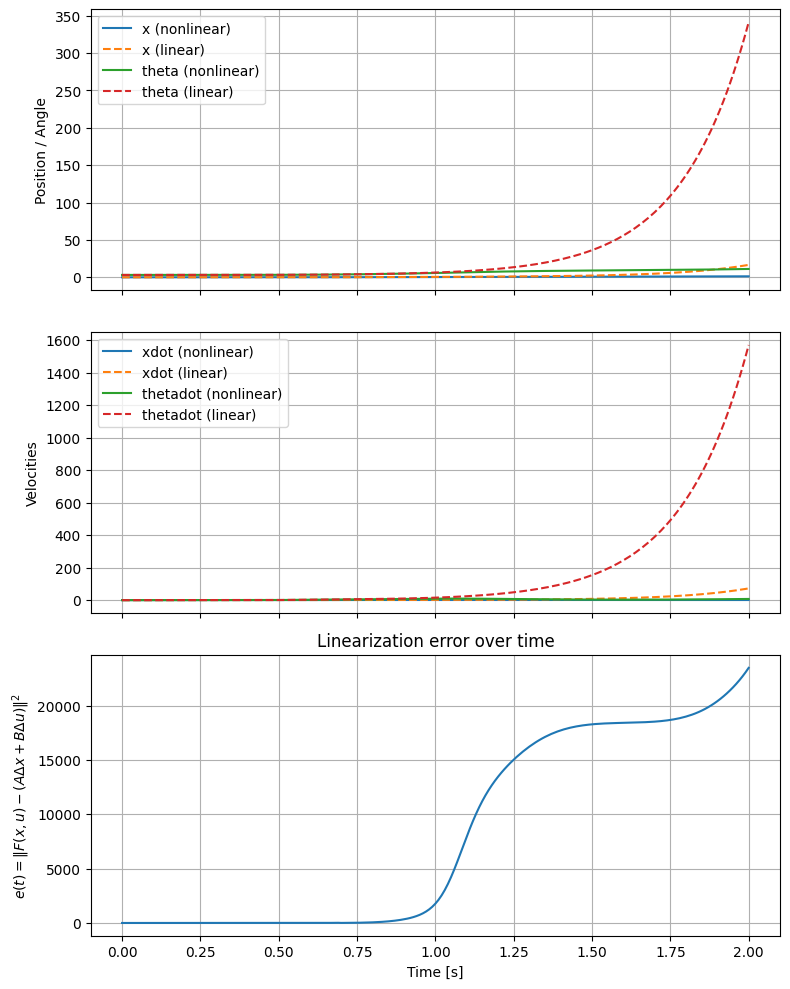

In [6]:
# Cart-pole: simulate nonlinear vs. linearized model and plot linearization error.
# Requirements: numpy, matplotlib

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Physical parameters (edit if needed)
# -----------------------------
m_c = 1.0   # cart mass [kg]
m_p = 0.1   # pole mass [kg]
l   = 0.5   # pole length [m]
g   = 9.81  # gravity [m/s^2]

# Upright equilibrium (x*, theta*, xdot*, thetadot*, u*)
x_star = np.array([0.0, np.pi, 0.0, 0.0])
u_star = np.array([0.0])

# -----------------------------
# Dynamics
# -----------------------------
def F(x, u):
    """
    Nonlinear cart-pole dynamics: x=[x, theta, xdot, thetadot]
    returns [xdot, thetadot, xddot, thetaddot]
    """
    ####################
    # TODO: Define the Nonlinear Dynamics here
    ####################
    x_pos, theta, xdot, thetadot = x
    f = u[0]
    den = m_c + m_p * np.sin(theta)**2

    xddot = (
        f
        + 0.5 * m_p * g * np.sin(2.0 * theta)   # m_p g sin(theta) cos(theta)
        + m_p * l * thetadot**2 * np.sin(theta)
    ) / den

    thetaddot = -(
        f * np.cos(theta)
        + (m_c + m_p) * g * np.sin(theta)
        + m_p * l * thetadot**2 * np.sin(theta) * np.cos(theta)
    ) / (l * den)

    return np.array([xdot, thetadot, xddot, thetaddot])


# Linearization matrices A, B
A = np.array([
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
    [0.0, g*m_p/m_c, 0.0, 0.0],
    [0.0, g*(m_c + m_p)/(l*m_c), 0.0, 0.0]
])

B = np.array([
    [0.0],
    [0.0],
    [1.0/m_c],
    [1.0/(l*m_c)]
])

def F_lin_state(x, u):
    """
    Linearized dynamics about (x_star, u_star):
        xdot ≈ A (x - x_star) + B (u - u_star)
    using the provided A and B matrices.
    """
    ####################
    # TODO: Define the linear Dynamics here
    ####################
    dx = x - x_star
    du = u - u_star
    return A @ dx + B[:, 0] * du[0]


# -----------------------------
# Integrator (RK4)
# -----------------------------
def rk4_step(f, x, u, dt):
    k1 = f(x, u)
    k2 = f(x + 0.5*dt*k1, u)
    k3 = f(x + 0.5*dt*k2, u)
    k4 = f(x + dt*k3, u)
    return x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)


# -----------------------------
# Input profiles (edit or add your own)
# -----------------------------
def make_u_fun(kind="zero", amp=5.0, t0=0.5, width=0.2, freq=1.0):
    """
    kind: "zero" | "step" | "pulse" | "sine"
    amp:  amplitude (N)
    t0:   step/pulse start (s)
    width:pulse width (s)
    freq: sine frequency (Hz)
    """
    if kind == "zero":
        return lambda t, x: 0.0
    if kind == "step":
        return lambda t, x: (amp if t >= t0 else 0.0)
    if kind == "pulse":
        return lambda t, x: (amp if (t0 <= t <= t0+width) else 0.0)
    if kind == "sine":
        return lambda t, x: amp*np.sin(2*np.pi*freq*t)
    raise ValueError("unknown kind")


# -----------------------------
# Simulation
# -----------------------------
def simulate_cartpole_error(x0, T=5.0, dt=0.01, u_kind="zero", **u_kwargs):
    """
    Simulate nonlinear and linearized models from initial state x0.
    Returns dict with time, states, and error e(t).
    """
    u_fun = make_u_fun(u_kind, **u_kwargs)

    ts = np.arange(0.0, T + dt, dt)
    X_nl = np.zeros((len(ts), 4))
    X_li = np.zeros((len(ts), 4))
    err  = np.zeros(len(ts))

    x_nl = x0.copy()
    x_li = x0.copy()

    for k, t in enumerate(ts):
        u = np.array([u_fun(t, x_nl)])

        # store
        X_nl[k] = x_nl
        X_li[k] = x_li

        # linearization error at the *nonlinear* state (definition in the exercise)
        e_vec = F(x_nl, u) - F_lin_state(x_nl, u)
        err[k] = float(np.dot(e_vec, e_vec))  # squared 2-norm

        # advance one step
        x_nl = rk4_step(F, x_nl, u, dt)
        x_li = rk4_step(F_lin_state, x_li, u, dt)

    return {"t": ts, "X_nl": X_nl, "X_lin": X_li, "e": err}


# -----------------------------
# Plotting
# -----------------------------
def plot_results(sim):
    ####################
    # TODO: plot result here
    ####################
    t   = sim["t"]
    X_nl  = sim["X_nl"]
    X_lin = sim["X_lin"]
    e   = sim["e"]

    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    axes[0].plot(t, X_nl[:, 0], label="x (nonlinear)")
    axes[0].plot(t, X_lin[:, 0], "--", label="x (linear)")
    axes[0].plot(t, X_nl[:, 1], label="theta (nonlinear)")
    axes[0].plot(t, X_lin[:, 1], "--", label="theta (linear)")
    axes[0].set_ylabel("Position / Angle")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(t, X_nl[:, 2], label="xdot (nonlinear)")
    axes[1].plot(t, X_lin[:, 2], "--", label="xdot (linear)")
    axes[1].plot(t, X_nl[:, 3], label="thetadot (nonlinear)")
    axes[1].plot(t, X_lin[:, 3], "--", label="thetadot (linear)")
    axes[1].set_ylabel("Velocities")
    axes[1].legend()
    axes[1].grid(True)

    axes[2].plot(t, e)
    axes[2].set_xlabel("Time [s]")
    axes[2].set_ylabel(r"$e(t) = \|F(x,u) - (A\Delta x + B\Delta u)\|^2$")
    axes[2].set_title("Linearization error over time")
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

x0 = np.array([0.0, np.pi + np.deg2rad(2.0), 0.0, 0.0])  # 10° from upright

sim = simulate_cartpole_error(
    x0,
    T=2.0,
    dt=0.01,
    u_kind="pulse",
    amp=5.0,
    t0=0.5,
    width=0.2,
    freq=1.0,
)
plot_results(sim)


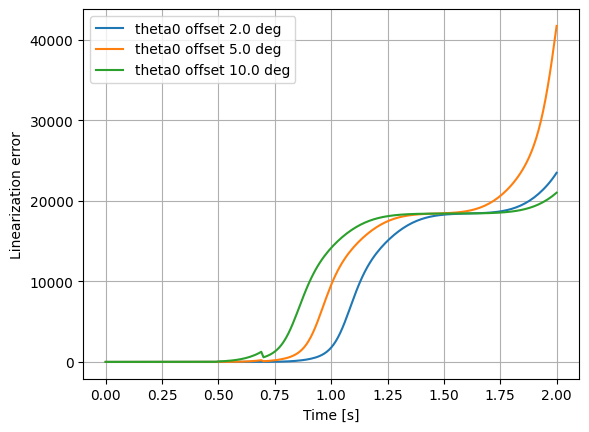

In [7]:
x0_list = [
    np.array([0.0, np.pi + np.deg2rad(2.0), 0.0, 0.0]),
    np.array([0.0, np.pi + np.deg2rad(5.0), 0.0, 0.0]),
    np.array([0.0, np.pi + np.deg2rad(10.0), 0.0, 0.0]),
]

for x0 in x0_list:
    sim = simulate_cartpole_error(x0, T=2.0, dt=0.01, u_kind="pulse",
                                  amp=5.0, t0=0.5, width=0.2)
    plt.plot(sim["t"], sim["e"], label=f"theta0 offset {np.rad2deg(x0[1]-np.pi):.1f} deg")

plt.xlabel("Time [s]")
plt.ylabel("Linearization error")
plt.legend()
plt.grid(True)
plt.show()


Using an RK4 integrator with time step $dt = 0.01$ and a pulse input of amplitude
$5\,\mathrm{N}$ applied between $t_0 = 0.5\,\mathrm{s}$ and $t_0 + 0.2\,\mathrm{s}$, we
simulate the nonlinear system $\dot{\mathbf{x}} = F(\mathbf{x}, u)$, and the linearized system $\dot{\mathbf{x}} \approx A (\mathbf{x} - \mathbf{x}^\star) + B (\mathbf{u} - \mathbf{u}^\star)$
from several initial conditions of the form
$
\mathbf{x}_0 = (0,\ \pi + \delta,\ 0,\ 0),
$
$\delta \in \{2^\circ, 5^\circ, 10^\circ\}
$.
For each run we record $e(t) = \| F(\mathbf{x}_{\text{nl}}(t), u(t))
- F_{\text{lin}}(\mathbf{x}_{\text{nl}}(t), u(t)) \|_2^2$, where
$\mathbf{x}_{\text{nl}}$ is the nonlinear trajectory and
$F_{\text{lin}}(x,u) := A(x - \mathbf{x}^\star) + B(u - \mathbf{u}^\star)$.

Thus we see that for a small initial offset ($\delta = 2^\circ$), the nonlinear and linear trajectories (both $x,\theta$ and their velocities) are almost indistinguishable up to roughly $t \approx 0.8$--$1.0\,\mathrm{s}$. In this interval, the error $e(t)$ remains essentially zero, so the linear model is an excellent approximation near the upright equilibrium and for short times. After the input pulse and as the pendulum angle and velocities grow, the trajectories begin to diverge and the error $e(t)$ rises sharply. This reflects that higher-order terms in $\sin\theta$ and $\cos\theta$ become important once $|\theta - \pi|$ and $|\dot{\theta}|$ are no longer small, so the first-order Taylor approximation breaks down. Comparing $\delta = 2^\circ, 5^\circ, 10^\circ$, the error curves show a clear pattern: the larger the initial deviation from upright, the earlier the error begins to grow. This illustrates that the region where the linearization is accurate shrinks as we move farther away from the equilibrium.
In all cases, once the trajectories move far from the equilibrium (large angle and angular velocity), the error grows very quickly and the linear and nonlinear trajectories diverge strongly, consistent with the instability of the upright cart--pole without feedback.

Overall, the simulations confirm that the linearized cart--pole model is a good
approximation only for small perturbations and short time horizons around the
upright equilibrium and as the state moves farther away (either because of a larger
initial offset or a strong input), the linearization error grows rapidly.


### 2.5 Discrete-time model and LQR design.
Convert the linear model in 2.3 to discrete time with step $dt$, then design a discrete LQR to stabilize the upright equilibrium. Does it work for all initial conditions?

**TODO:** Get the linear feedback control gain $K$ and simulate. Finish the code block.


/tmp/ipython-input-1994555414.py:104: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  U[k, 0] = u
/tmp/ipython-input-1994555414.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f = float(u)  # make sure u is a scalar


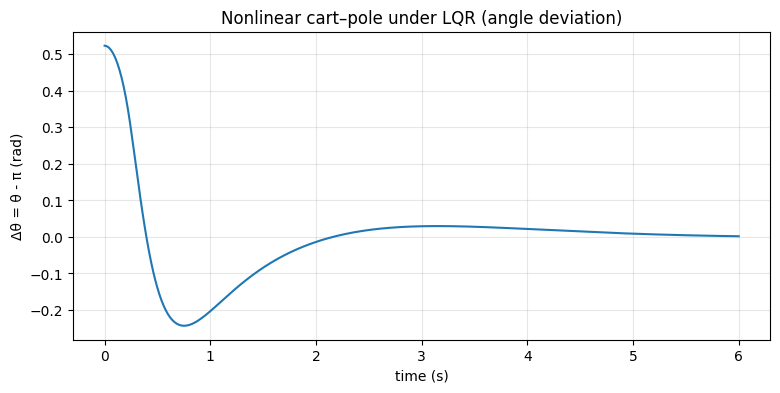

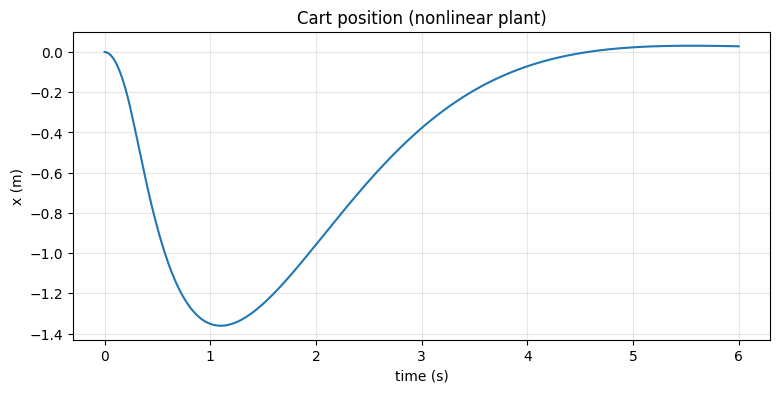

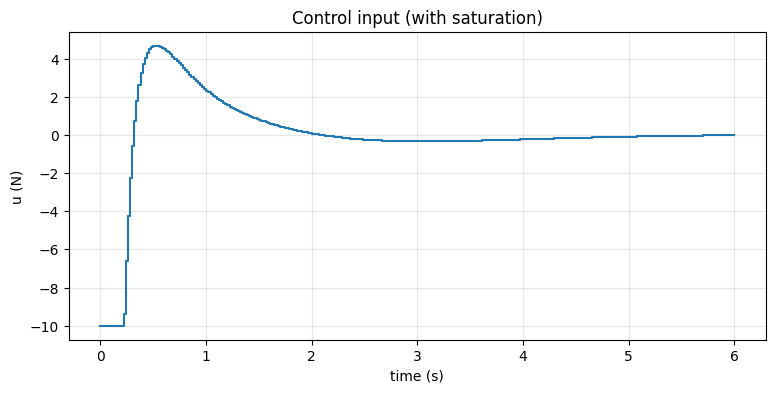

Final angle deviation (deg): 0.10317817538371385
Did it stabilize? (|Δθ| < 2° at end): True


In [10]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import solve_discrete_are


# -----------------------------
# Parameters
# -----------------------------
m_c = 1.0   # cart mass [kg]
m_p = 0.1   # pole mass [kg]
l   = 0.5   # pole length [m]
g   = 9.81  # gravity [m/s^2]

dt = 0.02   # discretization step for LQR and simulation [s]
T  = 6.0    # total simulation time [s]
N  = int(T / dt)

# LQR weights (tune as you like)
Q = np.diag([1.0, 50.0, 0.2, 1.0])  # penalize angle deviation strongly
R = np.array([[0.1]])               # control effort penalty

u_max = 10.0   # actuator saturation (set to None to disable)

# -----------------------------
# Nonlinear dynamics + integrator
# -----------------------------
def F_nonlinear(x, u, m_c=1.0, m_p=0.1, l=0.5, g=9.81):
    ####################
    # TODO: Finish the nonlinear dynamics here
    ####################
    # x = [x, theta, xdot, thetadot]
    x_pos, theta, xdot, thetadot = x
    f = float(u)  # make sure u is a scalar

    s = np.sin(theta)
    c = np.cos(theta)

    # Common denominator (from solving the 2x2 system)
    denom = m_c + m_p * s**2

    # xddot and thetaddot from the EoMs
    xddot = (f + m_p * l * thetadot**2 * s + m_p * g * s * c) / denom
    thetaddot = (-(m_c + m_p) * g * s - f * c
                 - m_p * l * thetadot**2 * s * c) / (l * denom)

    return np.array([xdot, thetadot, xddot, thetaddot])

def rk4_step(f, x, u, dt):
    k1 = f(x, u)
    k2 = f(x + 0.5*dt*k1, u)
    k3 = f(x + 0.5*dt*k2, u)
    k4 = f(x + dt*k3, u)
    return x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

# -----------------------------
# Build controller K, then simulate NONLINEAR plant
# -----------------------------
####################
# TODO: Build the K here
####################
M = m_c + m_p

A_c = np.array([
    [0.0, 0.0,  1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
    [0.0, (m_p*g)/m_c, 0.0, 0.0],
    [0.0, M*g/(l*m_c), 0.0, 0.0]
])

B_c = np.array([
    [0.0],
    [0.0],
    [1.0/m_c],
    [1.0/(l*m_c)]
])

# Forward-Euler discretization
A_d = np.eye(4) + dt * A_c
B_d = dt * B_c

# Solve discrete-time ARE and compute LQR gain
P = solve_discrete_are(A_d, B_d, Q, R)
K = np.linalg.inv(B_d.T @ P @ B_d + R) @ (B_d.T @ P @ A_d)

def simulate_nonlinear_from(x0, K, dt, N, u_max=None):
    """
    x0 is full state: [x, theta, xdot, thetadot].
    Control law: u = -K @ [Δx, Δθ, Δxdot, Δthetadot], where Δθ = theta - pi.
    """
    X = np.zeros((N+1, 4))
    U = np.zeros((N, 1))
    X[0] = x0
    for k in range(N):
        dx = np.array([
            X[k, 0],            # Δx (cart position about 0)
            X[k, 1] - np.pi,    # Δθ about upright
            X[k, 2],            # Δxdot
            X[k, 3],            # Δthetadot
        ])
        u = -K @ dx
        if u_max is not None:
            u = np.clip(u, -u_max, u_max)
        U[k, 0] = u
        X[k+1] = rk4_step(lambda x, uu: F_nonlinear(x, uu, m_c, m_p, l, g), X[k], u, dt)
    return X, U

x0 = np.array([0.0, np.pi + np.deg2rad(30.0), 0.0, 0.0])

X, U = simulate_nonlinear_from(x0, K, dt, N, u_max=u_max)

# -----------------------------
# Plot
# -----------------------------
t  = np.linspace(0.0, T, N+1)
tk = np.linspace(0.0, T, N)

plt.figure(figsize=(9, 4))
plt.plot(t, X[:,1] - np.pi)
plt.xlabel("time (s)")
plt.ylabel("Δθ = θ - π (rad)")
plt.title("Nonlinear cart–pole under LQR (angle deviation)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(t, X[:,0])
plt.xlabel("time (s)")
plt.ylabel("x (m)")
plt.title("Cart position (nonlinear plant)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 4))
plt.step(tk, U[:,0], where='post')
plt.xlabel("time (s)")
plt.ylabel("u (N)")
plt.title("Control input (with saturation)" if u_max is not None else "Control input")
plt.grid(True, alpha=0.3)
plt.show()

print("Final angle deviation (deg):", np.rad2deg(X[-1,1] - np.pi))
print("Did it stabilize? (|Δθ| < 2° at end):", abs(np.rad2deg(X[-1,1] - np.pi)) < 2.0)


In simulation we apply to the nonlineara cart–pole with
input saturation $|u|\le u_{\max}=10\,$N. For moderate initial deviations
(e.g. $\theta_0 = \pi + 30^\circ$ with zero velocities), the closed-loop
trajectories converge back to the upright equilibrium. The angle deviation
$\Delta\theta(t) = \theta(t)-\pi$ decays to nearly zero, the cart position
remains bounded, and the control input quickly comes out of saturation.

However, this LQR is only a local stabilizer as it is designed from the
linearization near $(x^\ast,\theta^\ast,\dot x^\ast,\dot\theta^\ast)$. For
larger initial angles or velocities (e.g. $\theta_0 = \pi + 60^\circ$,
$90^\circ$, etc.), the state leaves the region where the linear model is
accurate and the combination of strong nonlinearities and input saturation
causes the controller to fail to recover the upright position. Therefore the discrete LQR stabilizes the upright for small–moderate
initial deviations, but it doesnt work for all initial conditions.


## Problem 3 — Obstacle Avoidance with the CRISP Solver

Adapt Example 4.4 from the lecture notes to implement a trajectory optimization in Python using the CRISP solver. See the paper for details: [CRISP](https://computationalrobotics.seas.harvard.edu/CRISP/). Run the code locally, or copy `crisp.py` into your Google Colab folder.

CRISP need QP solver, for example I use PIQP here. Install the solver using `pip install 'qpsolvers[piqp]'`. You may change to other solvers by looking into CRISP's source code.

We consider a unicycle robot that must travel from a start pose **A** to a goal pose **B** while avoiding circular (disk) obstacles.

#### System Model
We use standard unicycle (Dubins-like) kinematics in continuous time:
$$
\dot{x}(t)
= \begin{bmatrix}\dot p_x\\ \dot p_y\\ \dot \theta\end{bmatrix}
= \begin{bmatrix} v(t)\cos\theta(t)\\ v(t)\sin\theta(t)\\ \omega(t) \end{bmatrix},\quad
x=\begin{bmatrix}p_x& p_y& \theta\end{bmatrix}^\top,\;
u=\begin{bmatrix}v&\omega\end{bmatrix}^\top.
$$

Discretize on a uniform grid $t_k=kh$ for $k=0,\ldots,N$ with step $h>0$ using forward Euler:
$$
x_{k+1} = f_h(x_k,u_k)
:= \begin{bmatrix}
p_{x,k} + h\, v_k \cos\theta_k\\
p_{y,k} + h\, v_k \sin\theta_k\\
\theta_k + h\, \omega_k
\end{bmatrix}.
$$

#### Decision Variables
Optimize over $\{x_k\}_{k=0}^{N}$ and $\{u_k\}_{k=0}^{N-1}$, collected as
$$
z=\big[ x_0^\top,\; u_0^\top,\; x_1^\top,\; u_1^\top,\; \ldots,\; x_{N-1}^\top,\; u_{N-1}^\top,\; x_N^\top \big]^\top
\in \mathbb{R}^{(3+2)N+3}.
$$

#### Constraints

**(i) Initial condition.**
$$
x_0 = A \in \mathbb{R}^3.
$$

**(ii) Dynamics (equalities), for $k=0,\ldots,N-1$.**
$$
x_{k+1} - f_h(x_k,u_k) = 0.
$$

**(iii) Obstacle avoidance (inequalities).**  
Let $\mathcal{O}=\{(c_j,r_j)\}_{j=1}^{n_{\text{obs}}}$ with centers $c_j=\begin{bmatrix}c_{x,j}&c_{y,j}\end{bmatrix}^\top$ and radii $r_j>0$. Enforce a safety margin $\delta\ge 0$ at each knot:
$$
(p_{x,k}-c_{x,j})^2 + (p_{y,k}-c_{y,j})^2 \;\ge\; (r_j+\delta)^2,
\qquad \forall k=0,\ldots,N,\ \forall j.
$$

**(iv) Box limits (controls, optionally states).**
$$
v_{\min}\le v_k \le v_{\max},\qquad
\omega_{\min}\le \omega_k \le \omega_{\max},\qquad
k=0,\ldots,N-1.
$$


### 4.1 Write down your optimization problem

According to the dynamics and the constraints, design the loss function yourself and write down the problem formulation as a mathematical optimization problem.

**Answer:**
We parameterize the unicycle by
$$
x_k =
\begin{bmatrix}
p_{x,k}\\[2pt]
p_{y,k}\\[2pt]
\theta_k
\end{bmatrix} \in \mathbb{R}^3,
\qquad
u_k =
\begin{bmatrix}
v_k\\[2pt]
\omega_k
\end{bmatrix} \in \mathbb{R}^2
$$
with forward–Euler dynamics
$$
x_{k+1} = f_h(x_k,u_k)
:=
\begin{bmatrix}
p_{x,k} + h\,v_k\cos\theta_k\\[2pt]
p_{y,k} + h\,v_k\sin\theta_k\\[2pt]
\theta_k + h\,\omega_k
\end{bmatrix},
\qquad k=0,\dots,N-1
$$

Given a start pose $A\in\mathbb{R}^3$, a goal pose $B\in\mathbb{R}^3$,
a set of circular obstacles
$$
\mathcal O = \{(c_j,r_j)\}_{j=1}^{n_{\mathrm{obs}}},
c_j =
\begin{bmatrix}c_{x,j}\\ c_{y,j}\end{bmatrix},\ r_j>0,
$$
and a safety margin $\delta \ge 0$, we choose a quadratic control–effort
objective
$$
J(x_{0:N},u_{0:N-1})
  = \sum_{k=0}^{N-1} u_k^\top R\,u_k,
R \in \mathbb{R}^{2\times 2},\ R \succ 0
$$

The trajectory–optimization problem then is
$$
\begin{aligned}
\min_{\{x_k,u_k\}} \quad &
\sum_{k=0}^{N-1} u_k^\top R\,u_k \\[4pt]
\text{s.t.}\quad
& x_0 = A, \\[2pt]
& x_N = B, \\[2pt]
& x_{k+1} = f_h(x_k,u_k),
   \qquad k = 0,\dots,N-1, \\[4pt]
& (p_{x,k} - c_{x,j})^2 + (p_{y,k} - c_{y,j})^2
   \;\ge\; (r_j + \delta)^2,\\
& \hspace{40mm} k = 0,\dots,N,\quad j = 1,\dots,n_{\mathrm{obs}}, \\[4pt]
& v_{\min} \le v_k \le v_{\max}, \qquad k = 0,\dots,N-1, \\[2pt]
& \omega_{\min} \le \omega_k \le \omega_{\max}, \qquad k = 0,\dots,N-1
\end{aligned}
$$


### 4.2 Program your problem and solve it using CRISP

Crisp's interface allow you to solve the problem

$$
\begin{align}
& \min_x f(x) \\
s.t. & \quad h(x) = 0\\
& \quad g(x) \geq 0\\
\end{align}
$$

When given the cost function $f$, its gradient and hessian $\nabla f, \nabla^2 f$, the equality and inequality constraint $h(x), g(x)$, and the jacobian of the constraint $\frac{\partial h}{\partial x}$ and $\frac{\partial g}{\partial x}$.

The code below provides a simple example:


In [13]:
!pip install "qpsolvers[piqp]"

  Using cached qpsolvers-4.8.2-py3-none-any.whl.metadata (12 kB)
  Using cached piqp-0.6.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (6.8 kB)
Using cached piqp-0.6.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (2.0 MB)
Using cached qpsolvers-4.8.2-py3-none-any.whl (92 kB)


In [16]:
from crisp import SQPSolver
import numpy as np

def cost(x):
    return x.dot(x)

def grad_cost(x):
    return 2*x

def hess_cost(x):
    return 2*np.eye(x.size)

def eq_cons(x):
    return np.array([ x[0] + x[1] - 1 ,
                        x[2] - x[3] + 1])

def jac_eq(x):
    return np.vstack([
        np.array([1,1,0,0,0]),
        np.array([0,0,1,-1,0])
    ])

def ineq_cons(x):

    return np.array([ x[2], x[3] ])

def jac_in(x):
    return np.vstack([
        np.array([0,0,1,0,0]),
        np.array([0,0,0,1,0])
    ])


x0 = np.zeros(5)

solver = SQPSolver(cost, grad_cost, hess_cost,
                    eq_cons, jac_eq,
                    ineq_cons, jac_in,
                    x0,
                    mu_eq_init=np.ones(2),
                    mu_in_init=np.ones(2),
                    max_iter=100)
x_opt, history = solver.solve()
print("Optimal x:", x_opt)

TR    predicted = 0.750000 , actual = 0.750000 , cost = 0.000000 , merit = 2.000000 , eq_vio = 1.000000 , in_vio = -0.000000 , QP_time = 0.002325s
REJ   predicted = 0.000000 , actual = 0.000000 , cost = 0.749971 , merit = 1.250000 , eq_vio = 0.499978 , in_vio = 0.000022 , QP_time = 0.000547s
Increase lower than tolerance at iter 1
TR+   predicted = 2.187760 , actual = 2.187760 , cost = 0.749971 , merit = 5.750260 , eq_vio = 0.499978 , in_vio = 0.000022 , QP_time = 0.000524s
TR    predicted = 2.062500 , actual = 2.062500 , cost = 1.062500 , merit = 3.562500 , eq_vio = 0.249949 , in_vio = 0.000051 , QP_time = 0.000545s
REJ   predicted = 0.000000 , actual = 0.000000 , cost = 1.500000 , merit = 1.500000 , eq_vio = 0.000000 , in_vio = 0.000000 , QP_time = 0.000497s
Solved at iter 4
Optimal x: [5.00000000e-01 5.00000000e-01 1.49686849e-10 1.00000000e+00
 0.00000000e+00]


Then your task is to implement the obstacle avoidance problem using CRISP. The code structure is given, but you need to fill in objective, constraints and its derivative.

**TODO:** Finish `TODO` functions.

TR+   predicted = 209.479167 , actual = 209.479167 , cost = 1220.000000 , merit = 1220.000000 , eq_vio = 0.000000 , in_vio = 0.000000 , QP_time = 0.007662s
TR+   predicted = 356.043274 , actual = 357.749725 , cost = 1010.020833 , merit = 1010.520833 , eq_vio = 0.053831 , in_vio = 0.000000 , QP_time = 0.008509s
TR+   predicted = 446.189809 , actual = 475.811657 , cost = 650.248311 , merit = 652.771108 , eq_vio = 1.376244 , in_vio = 0.852500 , QP_time = 0.010382s
TR+   predicted = 157.563776 , actual = 163.817354 , cost = 170.749444 , merit = 176.959451 , eq_vio = 3.535106 , in_vio = 1.322500 , QP_time = 0.009186s
TR    predicted = 5.210720 , actual = 5.173338 , cost = 5.832165 , merit = 13.142097 , eq_vio = 4.311064 , in_vio = 0.000000 , QP_time = 0.009728s
TR    predicted = 0.055571 , actual = 0.040526 , cost = 1.068005 , merit = 7.968760 , eq_vio = 4.216504 , in_vio = 0.000000 , QP_time = 0.007640s
TR    predicted = 0.012927 , actual = 0.011919 , cost = 1.142164 , merit = 7.928234 , e

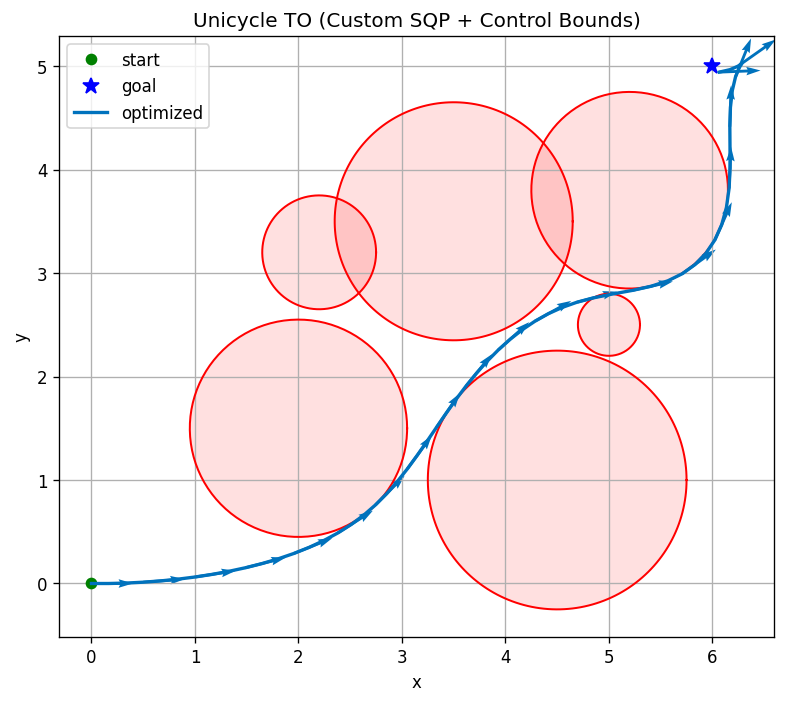

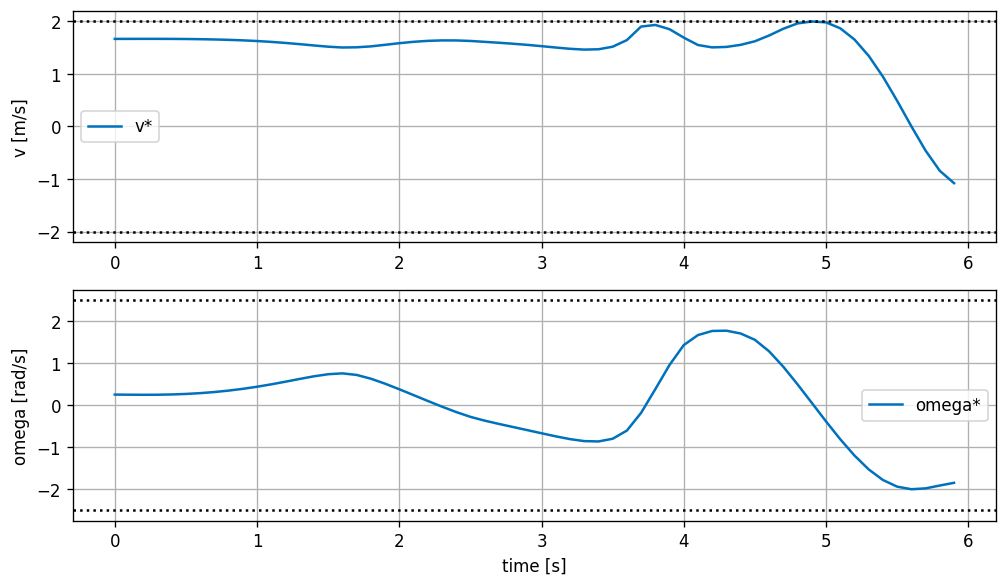

In [19]:
from __future__ import annotations

import math
from dataclasses import dataclass, field
from typing import Tuple

import numpy as np
from scipy import sparse as sp
import matplotlib.pyplot as plt

from crisp import SQPSolver


# -------------------- Problem parameters --------------------
@dataclass
class Params:
    N: int = 60
    h: float = 0.1
    A: np.ndarray = field(default_factory=lambda: np.array([0.0, 0.0, 0.0]))
    B: np.ndarray = field(default_factory=lambda: np.array([6.0, 5.0, 0.0]))
    obstacles: np.ndarray = field(default_factory=lambda: np.array([
        [2.0, 1.5, 0.8],
        [3.5, 3.5, 0.9],
        [5.2, 3.8, 0.7],
        [2.2, 3.2, 0.3],
        [4.5, 1.0, 1.0],
        [5.0, 2.5, 0.05],
    ]))
    safety_margin: float = 0.25

    v_min: float = -2.0
    v_max: float = 2.0
    w_min: float = -2.5
    w_max: float = 2.5

    w_goal_pos: float = 20.0
    w_goal_theta: float = 20.0
    w_u: float = 0.05
    w_du: float = 0.2

    n_x: int = 3
    n_u: int = 2

    def __post_init__(self):
        self.Z_DIM = (self.n_x + self.n_u) * self.N + self.n_x


# -------------------- Index helpers --------------------
def idx_x(k: int, p: Params) -> slice:
    base = (p.n_x + p.n_u) * k
    return slice(base, base + p.n_x)


def idx_u(k: int, p: Params) -> slice:
    base = (p.n_x + p.n_u) * k + p.n_x
    return slice(base, base + p.n_u)


# -------------------- Pack / Unpack --------------------
def pack(X: np.ndarray, U: np.ndarray, p: Params) -> np.ndarray:
    z = np.zeros(p.Z_DIM, dtype=float)
    for kk in range(p.N):
        z[idx_x(kk, p)] = X[kk, :]
        z[idx_u(kk, p)] = U[kk, :]
    z[idx_x(p.N, p)] = X[p.N, :]
    return z


def unpack(z: np.ndarray, p: Params) -> Tuple[np.ndarray, np.ndarray]:
    X = np.zeros((p.N + 1, p.n_x), dtype=float)
    U = np.zeros((p.N, p.n_u), dtype=float)
    for kk in range(p.N):
        X[kk, :] = z[idx_x(kk, p)]
        U[kk, :] = z[idx_u(kk, p)]
    X[p.N, :] = z[idx_x(p.N, p)]
    return X, U


# -------------------- Dynamics --------------------
def f_disc(xk: np.ndarray, uk: np.ndarray, h: float) -> np.ndarray:
    px, py, th = xk
    v, w = uk
    return np.array([
        px + h * v * math.cos(th),
        py + h * v * math.sin(th),
        th + h * w,
    ])

# -------------------- Objective & derivatives --------------------
def objective(z: np.ndarray, p: Params) -> float:
    ####################
    # TODO: Finish this
    ####################
    X, U = unpack(z, p)

    # terminal state
    pxN, pyN, thN = X[-1]
    pxB, pyB, thB = p.B

    # terminal position + heading
    J = 0.0
    J += p.w_goal_pos * ((pxN - pxB) ** 2 + (pyN - pyB) ** 2)
    J += p.w_goal_theta * (thN - thB) ** 2

    # control effort
    J += p.w_u * np.sum(U ** 2)

    # control smoothness: sum_{k=1}^{N-1} ||u_k - u_{k-1}||^2
    for k in range(1, p.N):
        du = U[k] - U[k - 1]
        J += p.w_du * float(du @ du)

    return float(J)



def grad_cost(z: np.ndarray, p: Params) -> np.ndarray:
    ####################
    # TODO: Finish this
    ####################
    X, U = unpack(z, p)
    g = np.zeros_like(z)

    # ----- terminal state gradient -----
    pxN, pyN, thN = X[-1]
    pxB, pyB, thB = p.B
    gxN = np.zeros(3)
    gxN[0] = 2.0 * p.w_goal_pos * (pxN - pxB)
    gxN[1] = 2.0 * p.w_goal_pos * (pyN - pyB)
    gxN[2] = 2.0 * p.w_goal_theta * (thN - thB)
    g[idx_x(p.N, p)] += gxN

    # ----- control effort gradient -----
    for k in range(p.N):
        uk = U[k]
        gu = 2.0 * p.w_u * uk
        g[idx_u(k, p)] += gu

    # ----- control smoothness gradient -----
    # J_du = w_du * sum_{k=1}^{N-1} ||u_k - u_{k-1}||^2
    for k in range(1, p.N):
        du = U[k] - U[k - 1]
        g[idx_u(k, p)]     += 2.0 * p.w_du * du
        g[idx_u(k - 1, p)] -= 2.0 * p.w_du * du

    return g




def hess_cost(z: np.ndarray, p: Params):
    ####################
    # TODO: Finish this
    ####################
    H = np.zeros((p.Z_DIM, p.Z_DIM))

    # ----- terminal position/heading Hessian -----
    # position
    ixN = idx_x(p.N, p)
    H[ixN.start + 0, ixN.start + 0] += 2.0 * p.w_goal_pos
    H[ixN.start + 1, ixN.start + 1] += 2.0 * p.w_goal_pos
    # heading
    H[ixN.start + 2, ixN.start + 2] += 2.0 * p.w_goal_theta

    # ----- control effort Hessian -----
    for k in range(p.N):
        iu = idx_u(k, p)
        H[iu.start + 0, iu.start + 0] += 2.0 * p.w_u
        H[iu.start + 1, iu.start + 1] += 2.0 * p.w_u

    # ----- control smoothness Hessian -----
    # Each term w_du * ||u_k - u_{k-1}||^2 contributes
    # 2*w_du * [[1, -1], [-1, 1]] on the (u_{k-1}, u_k) block (per dimension).
    for k in range(1, p.N):
        iu_prev = idx_u(k - 1, p)
        iu      = idx_u(k, p)
        for d in range(p.n_u):   # v and omega
            i = iu.start + d
            j = iu_prev.start + d
            H[i, i] += 2.0 * p.w_du
            H[j, j] += 2.0 * p.w_du
            H[i, j] += -2.0 * p.w_du
            H[j, i] += -2.0 * p.w_du

    return H


# -------------------- Constraints --------------------
def eq_cons(z: np.ndarray, p: Params) -> np.ndarray:
    ####################
    # TODO: Finish this
    ####################
    X, U = unpack(z, p)
    m_eq = 3 + 3 * p.N
    h = np.zeros(m_eq)

    # initial condition
    h[0:3] = X[0] - p.A

    # dynamics
    offset = 3
    for k in range(p.N):
        xk = X[k]
        uk = U[k]
        xkp1 = X[k + 1]
        h[offset:offset + 3] = xkp1 - f_disc(xk, uk, p.h)
        offset += 3

    return h




def jac_eq(z: np.ndarray, p: Params):
    ####################
    # TODO: Finish this
    ####################
    X, U = unpack(z, p)
    m_eq = 3 + 3 * p.N

    rows = []
    cols = []
    data = []

    # --- initial condition: h0 = x0 - A ---
    x0_slice = idx_x(0, p)
    for i in range(3):
        rows.append(i)
        cols.append(x0_slice.start + i)
        data.append(1.0)   # d(x0_i - A_i)/dx0_i = 1

    # --- dynamics constraints ---
    row_base = 3
    for k in range(p.N):
        xk_slice   = idx_x(k, p)
        xkp1_slice = idx_x(k + 1, p)
        uk_slice   = idx_u(k, p)

        px, py, th = X[k]
        v, w       = U[k]

        # partials of f_disc wrt x_k
        # f1 = px + h*v*cos(th)
        # f2 = py + h*v*sin(th)
        # f3 = th + h*w
        h_dt = p.h
        dfdx = np.array([
            [1.0, 0.0, -h_dt * v * math.sin(th)],
            [0.0, 1.0,  h_dt * v * math.cos(th)],
            [0.0, 0.0, 1.0],
        ])
        # partials wrt u_k
        dfdu = np.array([
            [h_dt * math.cos(th), 0.0],
            [h_dt * math.sin(th), 0.0],
            [0.0,                  h_dt],
        ])

        # h_dyn = x_{k+1} - f_disc(x_k,u_k)
        # so d h_dyn / d x_{k+1} = I,  d h_dyn / d x_k = -dfdx, d h_dyn / d u_k = -dfdu
        for i in range(3):
            r = row_base + 3 * k + i

            # derivative wrt x_{k+1}
            for j in range(3):
                rows.append(r)
                cols.append(xkp1_slice.start + j)
                data.append(1.0 if i == j else 0.0)

            # derivative wrt x_k
            for j in range(3):
                rows.append(r)
                cols.append(xk_slice.start + j)
                data.append(-dfdx[i, j])

            # derivative wrt u_k
            for j in range(2):
                rows.append(r)
                cols.append(uk_slice.start + j)
                data.append(-dfdu[i, j])

    J = sp.csr_matrix((data, (rows, cols)), shape=(m_eq, p.Z_DIM))
    return J



def ineq_cons(z: np.ndarray, p: Params) -> np.ndarray:
    ####################
    # TODO: Finish this
    ####################
    """Obstacle clearance + control box constraints, all as g(z) >= 0."""
    X, U = unpack(z, p)
    n_obs = p.obstacles.shape[0]
    m_in = (p.N + 1) * n_obs + 4 * p.N
    g = np.zeros(m_in)

    # obstacle constraints
    idx = 0
    for k in range(p.N + 1):
        px, py, _ = X[k]
        for j in range(n_obs):
            cx, cy, r = p.obstacles[j]
            r_eff = r + p.safety_margin
            g[idx] = (px - cx) ** 2 + (py - cy) ** 2 - r_eff ** 2
            idx += 1

    # control bounds
    for k in range(p.N):
        v, w = U[k]
        g[idx] = v - p.v_min   # v >= v_min
        idx += 1
        g[idx] = p.v_max - v   # v <= v_max
        idx += 1
        g[idx] = w - p.w_min   # w >= w_min
        idx += 1
        g[idx] = p.w_max - w   # w <= w_max
        idx += 1

    return g


def jac_in(z: np.ndarray, p: Params):
    ####################
    # TODO: Finish this
    ####################
    """Sparse Jacobian of ineq_cons matching the order in ineq_cons."""
    X, U = unpack(z, p)
    n_obs = p.obstacles.shape[0]
    m_in = (p.N + 1) * n_obs + 4 * p.N

    rows = []
    cols = []
    data = []

    # obstacle constraints
    row = 0
    for k in range(p.N + 1):
        x_slice = idx_x(k, p)
        px, py, _ = X[k]
        for j in range(n_obs):
            cx, cy, r = p.obstacles[j]
            # g = (px - cx)^2 + (py - cy)^2 - (r+δ)^2
            dpx = 2.0 * (px - cx)
            dpy = 2.0 * (py - cy)
            rows.append(row)
            cols.append(x_slice.start + 0)  # px
            data.append(dpx)
            rows.append(row)
            cols.append(x_slice.start + 1)  # py
            data.append(dpy)
            row += 1

    # control bounds
    for k in range(p.N):
        u_slice = idx_u(k, p)
        # v >= v_min  -> dv = 1
        rows.append(row)
        cols.append(u_slice.start + 0)
        data.append(1.0)
        row += 1

        # v <= v_max  -> d(v_max - v) = -1
        rows.append(row)
        cols.append(u_slice.start + 0)
        data.append(-1.0)
        row += 1

        # w >= w_min
        rows.append(row)
        cols.append(u_slice.start + 1)
        data.append(1.0)
        row += 1

        # w <= w_max
        rows.append(row)
        cols.append(u_slice.start + 1)
        data.append(-1.0)
        row += 1

    J = sp.csr_matrix((data, (rows, cols)), shape=(m_in, p.Z_DIM))
    return J


# -------------------- Plotting --------------------
def plot_results(p: Params, X: np.ndarray, U: np.ndarray) -> None:
    blue = (0.0, 0.4470, 0.7410)

    fig = plt.figure(figsize=(8, 6.5), dpi=120)
    ax = fig.add_subplot(111)
    ax.set_title("Unicycle TO (Custom SQP + Control Bounds)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)
    ax.set_aspect("equal", adjustable="box")

    ang = np.linspace(0, 2 * math.pi, 200)
    for j in range(p.obstacles.shape[0]):
        cx, cy, r = p.obstacles[j]
        r_eff = r + p.safety_margin
        ox = cx + r_eff * np.cos(ang)
        oy = cy + r_eff * np.sin(ang)
        ax.plot(ox, oy, "r-", linewidth=1.2)
        ax.fill(ox, oy, color=(1, 0, 0), alpha=0.12, edgecolor="none")

    ax.plot(p.A[0], p.A[1], "go", label="start")
    ax.plot(p.B[0], p.B[1], "b*", markersize=10, label="goal")

    ax.plot(X[:, 0], X[:, 1], color=blue, linewidth=2.0, label="optimized")

    skip = max(1, p.N // 20)
    for k in range(0, p.N + 1, skip):
        px, py, th = X[k]
        ax.quiver(px, py, 0.4 * math.cos(th), 0.4 * math.sin(th),
                  angles='xy', scale_units='xy', scale=1, color=blue, width=0.004)

    ax.legend(loc="best")

    t = np.arange(p.N) * p.h
    fig2 = plt.figure(figsize=(8.5, 5.0), dpi=120)

    ax1 = fig2.add_subplot(211)
    ax1.plot(t, U[:, 0], color=blue, label="v*")
    ax1.axhline(p.v_min, linestyle=":", color="k")
    ax1.axhline(p.v_max, linestyle=":", color="k")
    ax1.set_ylabel("v [m/s]")
    ax1.grid(True)
    ax1.legend()

    ax2 = fig2.add_subplot(212)
    ax2.plot(t, U[:, 1], color=blue, label="omega*")
    ax2.axhline(p.w_min, linestyle=":", color="k")
    ax2.axhline(p.w_max, linestyle=":", color="k")
    ax2.set_xlabel("time [s]")
    ax2.set_ylabel("omega [rad/s]")
    ax2.grid(True)
    ax2.legend()

    plt.tight_layout()
    plt.show()

p = Params()
X0, U0 = np.zeros((p.N + 1, p.n_x)), np.zeros((p.N, p.n_u))
z0 = pack(X0, U0, p)

cost_fn = lambda z: objective(z, p)
grad_fn = lambda z: grad_cost(z, p)
hess_fn = lambda z: hess_cost(z, p)
eq_fn   = lambda z: eq_cons(z, p)
jeq_fn  = lambda z: jac_eq(z, p)
in_fn   = lambda z: ineq_cons(z, p)
jin_fn  = lambda z: jac_in(z, p)

m_eq = 3 + 3 * p.N
m_in = (p.N + 1) * p.obstacles.shape[0] + 4 * p.N  # add 4 bounds per stage
mu_eq_init = 1.0 * np.ones(m_eq)
mu_in_init = 1.0 * np.ones(m_in)

solver = SQPSolver(cost_fn, grad_fn, hess_fn,
                    eq_fn, jeq_fn,
                    in_fn, jin_fn,
                    x0=z0,
                    mu_eq_init=mu_eq_init,
                    mu_in_init=mu_in_init,
                    delta_init=0.5,
                    delta_max=2.0,
                    tol=1e-6,
                    max_iter=2000)

z_star, hist = solver.solve()

X_star, U_star = unpack(z_star, p)
print("\nTerminal state [px py theta]^T = [" +
        f"{X_star[-1,0]:.3f} {X_star[-1,1]:.3f} {X_star[-1,2]:.3f}]")

plot_results(p, X_star, U_star)

CRISP’s trust-region SQP converged to a feasible solution (final eq/ineq violations ≈ 0, cost ≈ 11.3), producing a smooth unicycle trajectory that steers around all inflated disk obstacles while respecting the control bounds, and terminates within 9 cm and 2–3 deg of the goal pose.

## Problem 4: Model Predictive Control for Pendulum Swing-Up

A simple pendulum consists of a point mass $m$ attached to a massless rigid rod of length $\ell$ that pivots freely under gravity $g$. We measure the angle $\theta$ from the **upright** position ($\theta=0$), with angular velocity $\omega=\dot{\theta}$, so the state is $x=[\theta,\omega]^\top$ and the control input is a torque $\tau$ applied at the pivot. The classic **swing-up** problem starts near the downward equilibrium ($\theta\approx\pi,\ \omega\approx0$) and seeks a torque sequence that drives the pendulum to the upright ($\theta=0,\ \omega=0$) efficiently while respecting actuator limits.

<figure style="text-align:center;">
  <img src="https://raw.githubusercontent.com/ComputationalRobotics/2025-ES-AM-158-PSET/main/PSET4/invertedpendulum.png" width="360" alt="Pendulum schematic">
  <figcaption style="color:#6a737d; font-style:italic;">
    Figure 2. Pendulum.
  </figcaption>
</figure>

**State / input:** $x=\begin{bmatrix}\theta\\\omega\end{bmatrix}$, $u=\tau$ (torque)  

**Parameters:** mass $m$, length $\ell$, gravity $g$.

**Bounds:** $\tau(t)\in[\tau_{\min},\tau_{\max}]$.

**Dynamics**
$$
\dot\theta=\omega,\qquad
\dot\omega=-\frac{g}{\ell}\sin\theta+\frac{1}{m\ell^2}\,\tau .
$$

**Initial condition**
$$
x(0)=\begin{bmatrix}\pi\\0\end{bmatrix}\quad(\text{downward at rest}).
$$

**Objective**
$$
\min_{\tau(\cdot)} \int_0^{T}
\Big[
q_a\big(\sin^2\theta+(\cos\theta-1)^2\big)
+ q_\omega\,\omega^2
+ q_r \,\tau^2
\Big]\,dt
$$
subject to the dynamics, initial condition, and torque bounds.

Below is a simulation environment to test your controller.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def simulate_pendulum(u_fun,
                      x0=(0.01, 0.0), T=10.0, dt=0.01,
                      m=1.0, l=1.0, g=9.81,
                      tau_limits=None,
                      save_gif=False, gif_path="pendulum.gif", fps=None):
    """
    Simulate θ (upright=0) with torque policy u_fun(t, x) -> scalar.
    Returns (t, X, U). If save_gif, writes an animated GIF.
    """
    N = int(T/dt); t = np.linspace(0, T, N+1)
    X = np.zeros((N+1, 2)); X[0] = np.array(x0, float)
    U = np.zeros(N)

    def f(x, tt):
        th, w = x
        u = float(u_fun(tt, x))
        if tau_limits is not None: u = float(np.clip(u, tau_limits[0], tau_limits[1]))
        return np.array([w, (g/l)*np.sin(th) + u/(m*l*l)])

    def rk4(x, tt, h):
        k1 = f(x, tt)
        k2 = f(x + 0.5*h*k1, tt + 0.5*h)
        k3 = f(x + 0.5*h*k2, tt + 0.5*h)
        k4 = f(x + h*k3,     tt + h)
        return x + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)

    for k in range(N):
        th, w = X[k]
        u = float(u_fun(t[k], X[k]))
        if tau_limits is not None: u = float(np.clip(u, tau_limits[0], tau_limits[1]))
        U[k] = u
        X[k+1] = rk4(X[k], t[k], dt)

    if save_gif:
        xx_full = l*np.sin(X[:,0])
        yy_full = l*np.cos(X[:,0])

        stride = 10
        idx = np.arange(0, N+1, stride)
        xx, yy = xx_full[idx], yy_full[idx]
        fig, ax = plt.subplots(figsize=(5,5))
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlim(-1.15*l, 1.15*l); ax.set_ylim(-1.15*l, 1.15*l); ax.axis("off")
        ax.plot(0, 0, "o", ms=6, color="black")
        rod, = ax.plot([0, xx[0]], [0, yy[0]], lw=3, alpha=0.9)
        bob = plt.Circle((xx[0], yy[0]), 0.06*l, ec="black", lw=1.2, fc="#87CEFA")
        ax.add_patch(bob)
        def update(i):
            rod.set_data([0, xx[i]], [0, yy[i]])
            bob.center = (xx[i], yy[i])
            return rod, bob
        out_fps = max(1, int(1/(dt*stride))) if fps is None else fps
        ani = FuncAnimation(fig, update, frames=len(idx), interval=1000*dt*stride, blit=True)
        ani.save(gif_path, writer="pillow", fps=out_fps)
        plt.close(fig)

    return t, X, U


t, X, U = simulate_pendulum(lambda tt, x: 0.0, save_gif=True)



### 4.1 Trajectory optimization
With $N=50$ and $dt=0.1$, solve the trajectory optimization problem of swinging up the pendulum from the bottom right position: parameterize controls, discretize dynamics on each interval, and enforce control bound constraints. Plot your optimal trajectory and control signal.

This problem is similar to Problem 3.



Optimization terminated successfully    (Exit mode 0)
            Current function value: 340.9976063310474
            Iterations: 30
            Function evaluations: 4591
            Gradient evaluations: 30

Success: True | Status: 0
Message: Optimization terminated successfully
Final objective: 340.9976063310474


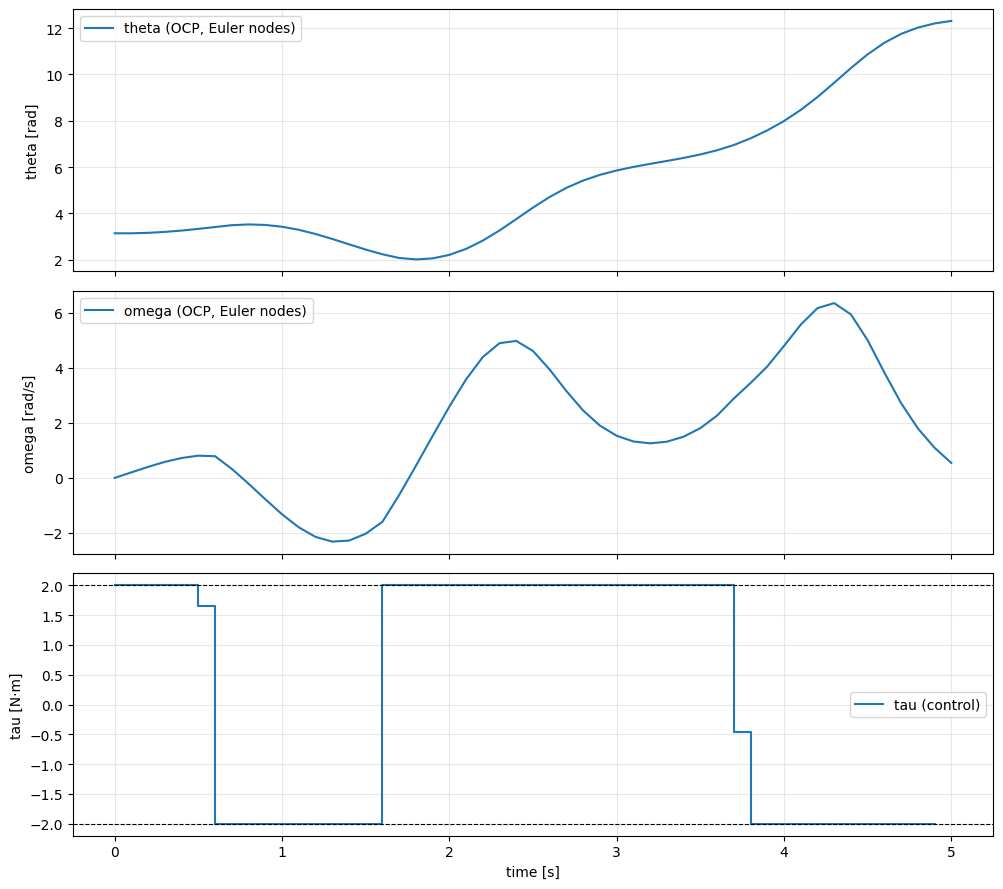

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, Bounds


# -----------------------------
# Problem setup (pendulum)
# -----------------------------
N = 50
dt = 0.1
T = N * dt
m, l, g = 1.0, 1.0, 9.81
x0 = np.array([np.pi, 0.0])  # [theta (upright=0), omega]

# cost weights
q_a, q_omega, q_r = 20.0, 2.0, 1e-2
u_min, u_max = -2.0, 2.0

def f_pend(x, u):
    th, w = x
    return np.array([w, (g/l)*np.sin(th) + u/(m*l*l)], dtype=float)

# -----------------------------
# Decision variables: z = [th_0..th_N, w_0..w_N, u_0..u_{N-1}]
# -----------------------------
def unpack(z):
    th = z[0:N+1]
    w  = z[N+1:2*(N+1)]
    u  = z[2*(N+1):]
    return th, w, u

def pack(th, w, u):
    return np.concatenate([th, w, u], axis=0)

# -----------------------------
# Objective (pendulum swing-up)
# J ≈ ∑ dt * [ q_a( sin^2 th + (cos th - 1)^2 ) + q_omega w^2 + q_r u^2 ]  (+ terminal state term)
# -----------------------------
def objective(z):
    ####################
    # TODO: Build objective here
    ####################
    th, w, u = unpack(z)
    J = 0.0
    # running cost
    for k in range(N):
        J_stage = (
            q_a * (np.sin(th[k])**2 + (np.cos(th[k]) - 1.0)**2)
            + q_omega * w[k]**2
            + q_r * u[k]**2
        )
        J += dt * J_stage
    # terminal state penalty (no torque term)
    thN, wN = th[-1], w[-1]
    J_term = q_a * (np.sin(thN)**2 + (np.cos(thN) - 1.0)**2) + q_omega * wN**2
    J += J_term
    return float(J)

# -----------------------------
# Multiple-shooting equality constraints (Euler)
# -----------------------------
def dynamics_constraints(z):
    ####################
    # TODO: Build the dynamic constraints here
    ####################
    th, w, u = unpack(z)
    c = np.zeros(2*(N+1))

    # initial condition
    c[0] = th[0] - x0[0]
    c[1] = w[0] - x0[1]

    # dynamics for k = 0..N-1
    idx = 2
    for k in range(N):
        # forward Euler
        th_next = th[k] + dt * w[k]
        w_next = w[k] + dt * ((g/l) * np.sin(th[k]) + u[k]/(m*l*l))

        c[idx] = th[k+1] - th_next
        c[idx+1] = w[k+1]  - w_next
        idx += 2

    return c


# -----------------------------
# Bounds
# -----------------------------
####################
# TODO: Finish Bounds
####################
z_dim = 2*(N+1) + N
lb = -np.inf * np.ones(z_dim)
ub = np.inf * np.ones(z_dim)

# torque part of z is last N entries
lb[2*(N+1):] = u_min
ub[2*(N+1):] = u_max
bounds = Bounds(lb, ub)

# -----------------------------
# Feasible initial guess (u=0 forward Euler)
# -----------------------------
####################
# TODO: Finish Initial bound
####################
u0 = np.zeros(N)
u0[:10]  =  2.0
u0[10:20] = -2.0
u0[20:30] =  2.0
u0[30:40] = -2.0
u0 = np.clip(u0, u_min, u_max)

th0 = np.zeros(N+1)
w0  = np.zeros(N+1)
th0[0], w0[0] = x0

for k in range(N):
    xk = np.array([th0[k], w0[k]])
    xkp1 = xk + dt * f_pend(xk, u0[k])
    th0[k+1], w0[k+1] = xkp1

z0 = pack(th0, w0, u0)


# -----------------------------
# Solve
# -----------------------------
eq_con = {'type': 'eq', 'fun': dynamics_constraints}

res = minimize(
    objective,
    z0,
    method='SLSQP',
    bounds=bounds,
    constraints=[eq_con],
    options={'maxiter': 500, 'ftol': 1e-4, 'disp': True},
)

print("\nSuccess:", res.success, "| Status:", res.status)
print("Message:", res.message)
print("Final objective:", res.fun)

# -----------------------------
# Extract & verify by RK4 sim with u_k (piecewise-constant)
# -----------------------------
th_sol, w_sol, u_sol = unpack(res.x)
t_nodes = np.linspace(0.0, T, N+1)
t_ctrl  = np.linspace(0.0, T - dt, N)


# -----------------------------
# Plots
# -----------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(t_nodes, th_sol, label="theta (OCP, Euler nodes)")
axes[0].set_ylabel("theta [rad]"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(t_nodes, w_sol, label="omega (OCP, Euler nodes)")
axes[1].set_ylabel("omega [rad/s]"); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].step(t_ctrl, u_sol, where='post', label="tau (control)")
axes[2].axhline(u_min, ls='--', c='k', lw=0.8); axes[2].axhline(u_max, ls='--', c='k', lw=0.8)
axes[2].set_xlabel("time [s]"); axes[2].set_ylabel("tau [N·m]"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()


### 4.2 Failure of open loop control

Now we solved out a trajectory with a given initial state. However, does this imply that if we simply run the planned controls on a real system, i.e., doing open-loop control, the trajectory will behave as planned? Unfortunately the answer is No, trajectory optimization only produces an approximate solution to the optimal control problem (OCP), regardless of what transcription method is used. So the error may cumulate along time horizon.

Rollout the control to see the fail of swing up.

**TODO:** Finish the code and comment on what you see.

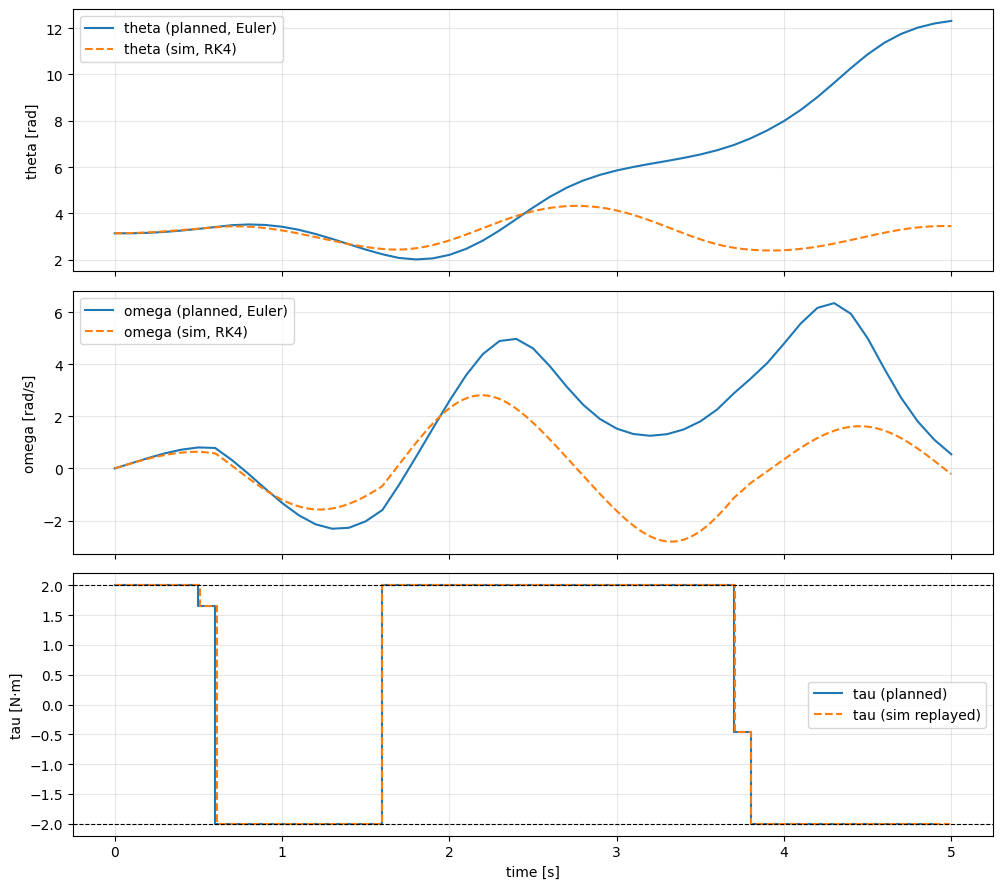

In [3]:
def u_fun(t, x):
    k = int(t // dt)
    if k < 0: k = 0
    if k >= len(u_sol): k = len(u_sol) - 1
    return float(u_sol[k])  # open-loop (ignores x)

# --- “real-world” simulation (can be finer dt than planning; choose dt_sim) ---
dt_sim = 0.01  # finer integration for verification
t_sim, X_sim, U_sim = simulate_pendulum(
    u_fun,
    x0=x0, T=T,
    tau_limits=(u_min, u_max),
    save_gif=True  # set True to export an animation
)

###################
# TODO: Plot here
###################
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# angle
axes[0].plot(t_nodes, th_sol, 'C0-', label="theta (planned, Euler)")
axes[0].plot(t_sim,   X_sim[:,0], 'C1--', label="theta (sim, RK4)")
axes[0].set_ylabel("theta [rad]")
axes[0].legend()
axes[0].grid(alpha=0.3)

# angular velocity
axes[1].plot(t_nodes, w_sol, 'C0-', label="omega (planned, Euler)")
axes[1].plot(t_sim,   X_sim[:,1], 'C1--', label="omega (sim, RK4)")
axes[1].set_ylabel("omega [rad/s]")
axes[1].legend()
axes[1].grid(alpha=0.3)

# torque
t_ctrl = np.linspace(0.0, T - dt, N)
axes[2].step(t_ctrl, u_sol, where='post', label="tau (planned)")
axes[2].step(t_sim[:-1], U_sim, where='post', linestyle='--', label="tau (sim replayed)")
axes[2].axhline(u_min, ls='--', c='k', lw=0.8)
axes[2].axhline(u_max, ls='--', c='k', lw=0.8)
axes[2].set_xlabel("time [s]")
axes[2].set_ylabel("tau [N·m]")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

We compare the OCP solution (forward Euler with $dt=0.1$) to an
open–loop rollout of the same control sequence on the continuous pendulum
simulated with RK4 ($dt_\text{sim}=0.01$). The torque trajectories essentially
overlap, confirming that we are replaying the same sequence $u_k$. However, the
state trajectories diverge over time: initially $\theta(t)$ and $\omega(t)$ for
the planned and simulated systems agree closely, but the mismatch grows along
the horizon. By the final time the simulated pendulum is far from the
predicted terminal state. This shows that the open–loop trajectory produced by
the discretized OCP is only approximate because integration and modeling errors in
this nonlinear system accumulate, so simply replaying the optimized controls
does not reliably achieve swing–up.

### 4.3 Model Predictive Control

Now we will use model predictive control to get a feedback controller.
Basically at every time step, we solve a trajectory optimization problem to obtain an open-loop state-control trajectory, but we only execute the first control input.
Executing the first control input will bring the system to a new state, and we resolve the trajectory optimization problem with this new initial state.
When solving the new TO problem, you can reuse the solution from previous solve as the initial guess.

**TODO:** Finish the code and plot the final trajectory

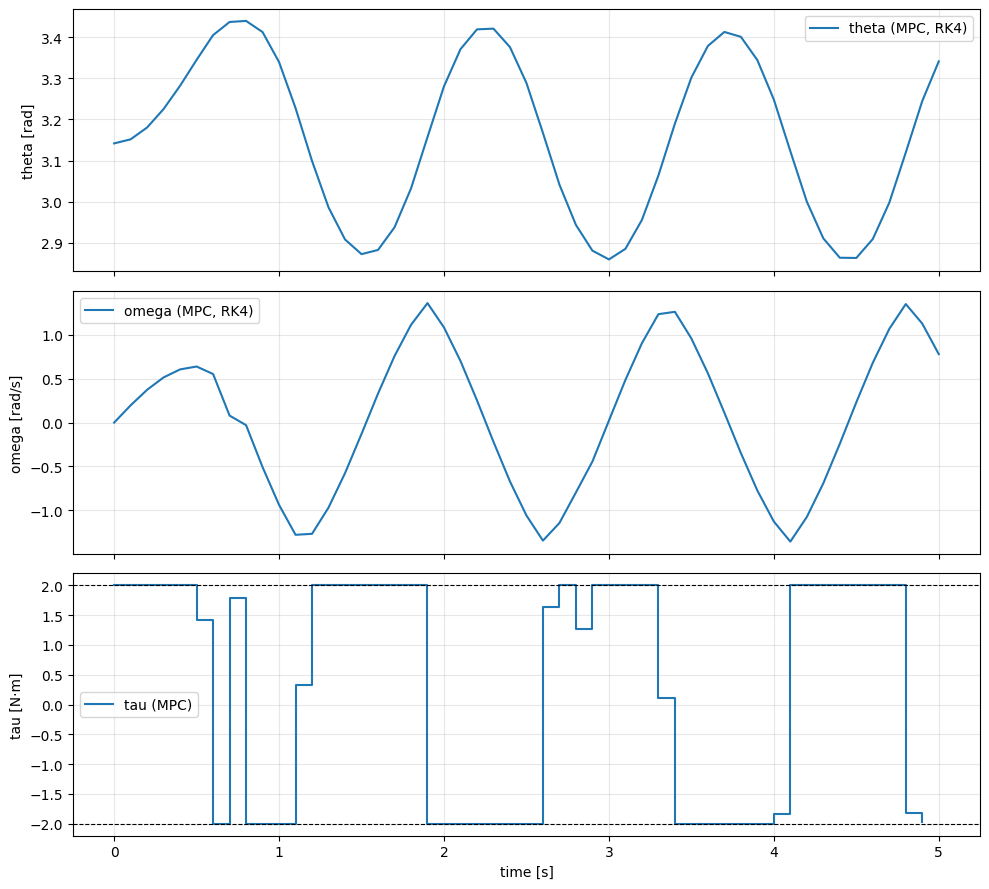

In [6]:
##############################
# TODO: reuse your code in 4.1 to finish this
##############################
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, Bounds

N = 50
dt = 0.1
T = N * dt
m, l, g = 1.0, 1.0, 9.81
x0 = np.array([np.pi, 0.0])   # [theta (upright=0), omega]

q_a, q_omega, q_r = 20.0, 2.0, 1e-2
u_min, u_max = -2.0, 2.0

def f_pend(x, u):
    th, w = x
    return np.array([w, (g/l)*np.sin(th) + u/(m*l*l)], dtype=float)

# decision variable packing/unpacking from 4.1
def unpack(z):
    th = z[0:N+1]
    w  = z[N+1:2*(N+1)]
    u  = z[2*(N+1):]
    return th, w, u

def pack(th, w, u):
    return np.concatenate([th, w, u], axis=0)

def objective(z):
    th, w, u = unpack(z)
    J = 0.0
    for k in range(N):
        J_stage = (
            q_a * (np.sin(th[k])**2 + (np.cos(th[k]) - 1.0)**2)
            + q_omega * w[k]**2
            + q_r * u[k]**2
        )
        J += dt * J_stage
    thN, wN = th[-1], w[-1]
    J_term = q_a * (np.sin(thN)**2 + (np.cos(thN) - 1.0)**2) + q_omega * wN**2
    J += J_term
    return float(J)

# ----- (time-invariant) bounds on z -----
z_dim = 2*(N+1) + N
lb = -np.inf * np.ones(z_dim)
ub =  np.inf * np.ones(z_dim)
lb[2*(N+1):] = u_min
ub[2*(N+1):] = u_max
bounds = Bounds(lb, ub)

# ----- helper: dynamics constraints with given initial state x_init -----
def make_dyn_con(x_init):
    """
    Return a function c(z) implementing multiple-shooting constraints
    with initial condition x_init = [theta0, omega0].
    """
    def dyn_con(z):
        th, w, u = unpack(z)
        c = np.zeros(2*(N+1))

        # initial condition
        c[0] = th[0] - x_init[0]
        c[1] = w[0]  - x_init[1]

        # forward Euler dynamics
        idx = 2
        for k in range(N):
            th_next = th[k] + dt * w[k]
            w_next  = w[k] + dt * ((g/l) * np.sin(th[k]) + u[k]/(m*l*l))

            c[idx]   = th[k+1] - th_next
            c[idx+1] = w[k+1]  - w_next
            idx += 2

        return c
    return dyn_con

# ----- initial guess for the first solve (same style as 4.1) -----
u_guess = np.zeros(N)
u_guess[:10]  =  2.0
u_guess[10:20] = -2.0
u_guess[20:30] =  2.0
u_guess[30:40] = -2.0
u_guess = np.clip(u_guess, u_min, u_max)

th_guess = np.zeros(N+1)
w_guess  = np.zeros(N+1)
th_guess[0], w_guess[0] = x0

for k in range(N):
    xk   = np.array([th_guess[k], w_guess[k]])
    xkp1 = xk + dt * f_pend(xk, u_guess[k])
    th_guess[k+1], w_guess[k+1] = xkp1

z_guess = pack(th_guess, w_guess, u_guess)

# ----- RK4 integrator for the "real" plant -----
def rk4_step(x, u, h):
    k1 = f_pend(x, u)
    k2 = f_pend(x + 0.5*h*k1, u)
    k3 = f_pend(x + 0.5*h*k2, u)
    k4 = f_pend(x + h*k3,     u)
    return x + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)

# ==========================================
# MPC loop
# ==========================================
T_mpc = 5.0          # total closed-loop time
K     = int(T_mpc/dt)

X_mpc = np.zeros((K+1, 2))
U_mpc = np.zeros(K)
t_mpc = np.linspace(0.0, T_mpc, K+1)
t_u   = np.linspace(0.0, T_mpc - dt, K)

x_curr = x0.copy()
X_mpc[0] = x_curr

for k in range(K):
    # build equality constraint with current state
    dyn_con = make_dyn_con(x_curr)
    eq_con  = {'type': 'eq', 'fun': dyn_con}

    # solve OCP with warm start
    res = minimize(
        objective,
        z_guess,
        method='SLSQP',
        bounds=bounds,
        constraints=[eq_con],
        options={'maxiter': 200, 'ftol': 1e-4, 'disp': False},
    )

    if not res.success:
        print(f"[MPC] Warning: solver failed at step {k}, status={res.status}")
        # fall back to zero torque
        u0 = 0.0
    else:
        th_opt, w_opt, u_opt = unpack(res.x)
        u0 = float(u_opt[0])   # first control only
        z_guess = res.x        # warm-start next iteration

    U_mpc[k] = u0
    # apply u0 to the true system for one step
    x_curr = rk4_step(x_curr, u0, dt)
    X_mpc[k+1] = x_curr

# ==========================================
# Plots
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axes[0].plot(t_mpc, X_mpc[:,0], label="theta (MPC, RK4)")
axes[0].set_ylabel("theta [rad]")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(t_mpc, X_mpc[:,1], label="omega (MPC, RK4)")
axes[1].set_ylabel("omega [rad/s]")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].step(t_u, U_mpc, where='post', label="tau (MPC)")
axes[2].axhline(u_min, ls='--', c='k', lw=0.8)
axes[2].axhline(u_max, ls='--', c='k', lw=0.8)
axes[2].set_xlabel("time [s]")
axes[2].set_ylabel("tau [N·m]")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


We implemented MPC by re-solving the swing-up OCP at each time step with horizon
$N = 50$ and step size $dt = 0.1$, using the previous solution as a warm start
and applying only the first control input. The resulting closed-loop trajectory
does not swing the pendulum to the upright, instead, $\theta(t)$
remains near $\pi$ and $\omega(t)$ oscillates with small amplitude. The
finite-horizon nonlinear OCP repeatedly converges to a local solution that keeps
the pendulum rocking around the bottom rather than committing to a full swing.

